<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC3</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# PEC 3: Métodos supervisados

En esta práctica veremos diferentes métodos supervisados y trataremos de optimizar diferentes métricas. Veremos como los diferentes modelos clasifican las observaciones y con cuales obtendremos mayor rendimiento. Después aplicaremos todo lo que sabemos de análisis, procesamiento de datos y regresión a un dataset nuevo simulando un caso práctico real.

1. [Exploración de algoritmos supervisados](#ej1) \
    1.1. [Carga de datos](#ej11) \
    1.2. [K vecinos más próximos (KNN)](#ej13) \
    1.3. [Máquinas de soporte vectorial (SVM)](#ej14) \
    1.4. [Árboles de decisión](#ej15) 
4. [Implementación del caso práctico](#ej2)\
    2.1. [Carga de datos](#ej21) \
    2.2. [Análisis estadístico básico y exploratorio de datos](#ej22) \
    2.3. [Preprocesamiento de datos](#ej23) \
    2.4. [Modelización](#ej24) \
    2.5. [TabPFN](#ej25)

<u>Consideraciones generales</u>:

- La solución planteada no puede utilizar métodos, funciones o parámetros declarados **_deprecated_** en futuras versiones, a excepción de la carga de datos cómo se indica posteriormente.
- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.
- En esta PEC se permite el uso de la IA para explorar mejoras en las visualizaciones creadas y para profundizar en el análisis de los resultados que hayáis obtenido por vuestra cuenta, siempre detallando los prompts y respuestas producidas y desde una perspectiva crítica que incluya vuestra argumentación, dejando claro en qué estáis de acuerdo con la IA y en qué no.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
    <strong>Nombre y apellidos: Víctor Suesta Arribas</strong>
</div>

La siguiente celda carga la mayor parte de los módulos que necesitaréis para el desarrollo de la tercera PEC.

In [1]:
import pickle

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from umap import UMAP

<a id='ej1'></a>
# 1. Exploración de algoritmos supervisados (4.5 puntos)

En este apartado exploraremos el comportamiento de las diferentes técncias de clasificación vistas en la teoría aplicadas a un conjunto de datos muy visual.

<a id='ej11'></a>
## 1.1. Carga y preparación de los datos (0.75 puntos)

El conjunto de datos EMNIST (Extended Modified National Institute of Standards and Technology) es una ampliación del clásico MNIST dataset, ampliamente utilizado en tareas de visión por computador. Mientras que MNIST contiene únicamente imágenes de dígitos manuscritos (0–9), EMNIST incorpora también letras del alfabeto (mayúsculas y/o minúsculas, según la partición), lo que lo convierte en un recurso más completo y desafiante para entrenar y evaluar modelos de reconocimiento de caracteres. <i>Cohen, G., Afshar, S., Tapson, J., & van Schaik, A. (2017). EMNIST: an extension of MNIST to handwritten letters. Retrieved from http://arxiv.org/abs/1702.05373</i>

En esta actividad utilizaremos el subconjunto de las letras mayúsculas (A, J, L, M, S) proyectadas a un espacio de dos dimensiones para poder entender de forma visual cómo funciona cada uno de los algoritmos de clasificación plasmando sus fronteras de decisión.

Lo primero que haremos es cargar el conjunto de datos:

In [2]:
with open('EMNIST_sample.pickle', 'rb') as dump_file:
    X, y = pickle.load(dump_file)

n_classes = np.unique(y).size
print(f"# clases: {n_classes}")

labels = ["A", "J", "L", "M", "S"]

# clases: 5


Con el siguiente código veremos un ejemplo de imagen de cada una de las clases. Para ello reajustaremos el vector de 784 dimensiones que representa cada imagen en una matriz de tamaño 28x28 para poder mostrarla:

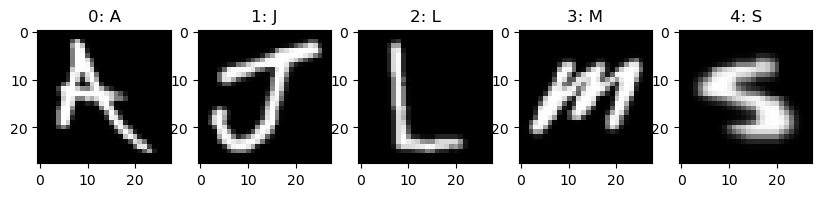

In [3]:
fig, ax = plt.subplots(1, n_classes, figsize=(10,5))

idxs = [np.where(y == i)[0] for i in range(n_classes)]

for i in range(n_classes):
    k = np.random.choice(idxs[i])
    ax[i].imshow(X[k].reshape(28, 28), cmap="gray")
    ax[i].set_title("{}".format(f"{i}: {labels[i]}"))

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Dividid el _dataset_ en dos subconjuntos, __*train*__ (80% de los datos) y __*test*__ (20% de los datos). Nombrad los conjuntos como: X_train, X_test, y_train, y_test. Utilizad la opción `random_state = 24`. Podéis utilizar la implementación `train_test_split` de `sklearn`.    

</div>

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=24
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5992, 784)
X_test shape: (1499, 784)
y_train shape: (5992,)
y_test shape: (1499,)


Para poder visualizar los resultados de cada algoritmo supervisado, reduciremos el dataset anterior a dos dimensiones.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Utiliza UMAP para reducir tanto el conjunto de datos de entrenamiento como de test a dos dimensiones.    

</div>

In [5]:
umap_model = UMAP(n_components=2)

X_train_projection = umap_model.fit_transform(X_train)
X_test_projection = umap_model.transform(X_test)

print(f"X_train_projection shape: {X_train_projection.shape}")
print(f"X_test_projection shape: {X_test_projection.shape}")

X_train_projection shape: (5992, 2)
X_test_projection shape: (1499, 2)


A lo largo del ejercicio aprenderemos a ver gráficamente las fronteras de decisión que nos devuelven los diferentes modelos. Para ello utilizaremos la función definida a continuación, que sigue los siguientes pasos:

1. Crear una meshgrid con los valores mínimo y máximo de 'x' e 'y'.
2. Predecir el clasificador con los valores de la meshgrid.
3. Hacer un reshape de los datos para tener el formato correspondiente.

Una vez hecho esto, ya podemos hacer el gráfico de las fronteras de decisión y añadir los puntos reales. Así veremos las áreas que el modelo considera que son de una clase y las que considera que son de otra. Al poner encima los puntos veremos si los clasifica correctamente en el área que les corresponde.

In [6]:
# Define the function that will visualize the decision boundary
def plot_decision_boundaries(model, X_test_projection, y_test):

    # Create the meshgrid with the minimum and maximum values of the x and y axes
    x_min, x_max = X_test_projection[:, 0].min() - 1, X_test_projection[:, 0].max() + 1
    y_min, y_max = X_test_projection[:, 1].min() - 1, X_test_projection[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Prediction by using all values of the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Define the colors (one for each class)
    cmap_light = ListedColormap(['gainsboro','lightgreen','peachpuff','lightcyan', 'pink'])
    cmap_bold = ['grey', 'g','sandybrown','c','palevioletred']
    
    # Draw the borders
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(20,10))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Draw the points
    for i in range(n_classes):
        plt.scatter(X_test_projection[y_test == i,0], X_test_projection[y_test == i,1], 
                    s=40, marker='o', label=labels[i], c=cmap_bold[i])
    plt.legend(loc='best')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

<a id='ej12'></a>
## 1.2. KNN (1.25 puntos)

En este punto, vas a entender el funcionamiento del algoritmo KNN (K-Nearest-Neighbor), que se basa en la proximidad de los puntos de datos en un espacio de características. Analizarás sus ventajas y desventajas, y comprenderás cómo los parámetros que lo componen influyen en su comportamiento.

KNN es un algoritmo de tipo supervisado basado en instancia. Esto significa:

- Supervisado: Tu conjunto de datos de entrenamiento está etiquetado con la clase o resultado esperado.
- Basado en instancia (_Lazy Learning_): El algoritmo no aprende explícitamente un modelo, como en la Regresión Logística o los árboles de decisión. En cambio, memoriza las instancias de entrenamiento y las utiliza como "conocimiento" en la fase de predicción.

Para entender cómo funciona KNN, sigue estos pasos:

1. Calcula la distancia entre el ítem a clasificar y los demás ítems del dataset de entrenamiento.
2. Selecciona los "k" elementos más cercanos, es decir, aquellos con la menor distancia, según el tipo de distancia que utilices (euclídea, coseno, manhattan, etc).
3. Realiza una "votación de mayoría" entre los k puntos seleccionados: la clase que predomine en estos puntos decidirá la clasificación final del ítem analizado.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Realiza los siguientes pasos con el dataset de entrenamiento (_train_):

1. Entrena un clasificador KNN con el hiperparámetro `n_neighbors=2` usando el clasificador `KNeighborsClassifier` de `sklearn`.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Si al entrenar el clasificador aparece un aviso (warning) y deseas ignorarlo, ejecuta el siguiente código antes del entrenamiento:

`import warnings`
`warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)`"

Esto te permitirá evaluar la efectividad del modelo KNN con `n_neighbors=2` en tu conjunto de datos, y entender cómo se comporta en términos de clasificación y separación de clases.    
    
    
    
</div>

Accuracy en train con k=2: 0.9743
Accuracy en test con k=2: 0.9400

Matriz de confusión en test:
[[212   5   2   2   4]
 [  2 110   1   0   6]
 [  5   3 149   0   0]
 [ 14   2   0 277   1]
 [  2  40   1   0 661]]


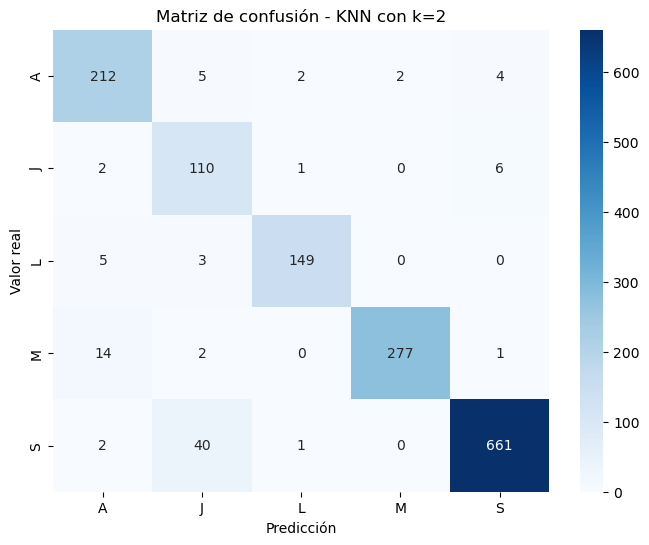

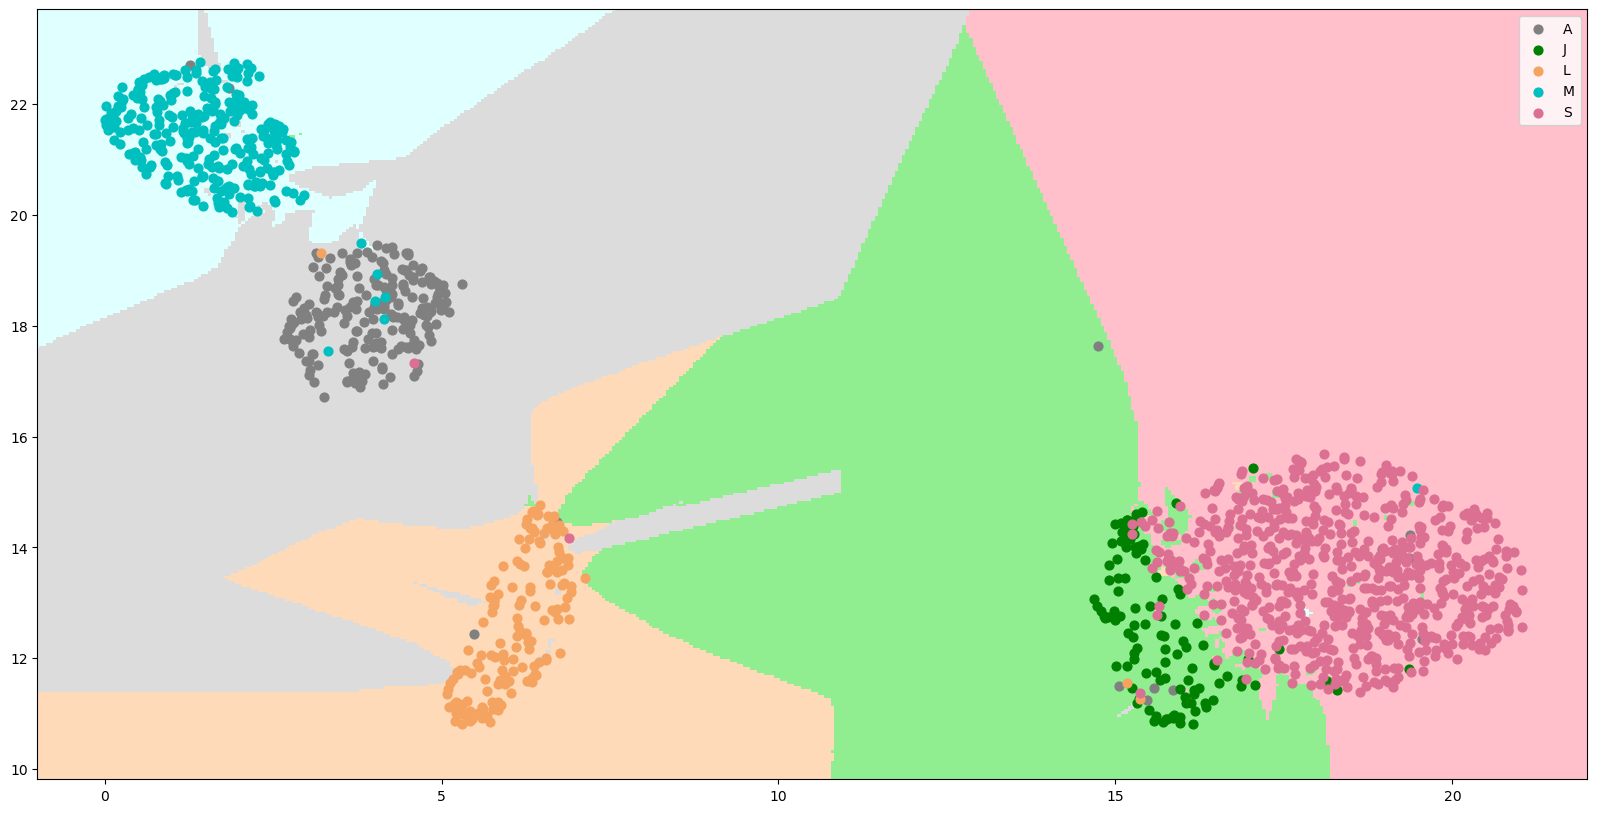

In [7]:
# Entreno un modelo KNN con n_neighbors = 2
import warnings
warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)

knn_2 = KNeighborsClassifier(n_neighbors=2)
knn_2.fit(X_train_projection, y_train)

# Hago predicciones en train y test
y_train_pred_knn_2 = knn_2.predict(X_train_projection)
y_test_pred_knn_2 = knn_2.predict(X_test_projection)

# Calculo accuracy en train y test
acc_train_knn_2 = accuracy_score(y_train, y_train_pred_knn_2)
acc_test_knn_2 = accuracy_score(y_test, y_test_pred_knn_2)

print(f"Accuracy en train con k=2: {acc_train_knn_2:.4f}")
print(f"Accuracy en test con k=2: {acc_test_knn_2:.4f}")

# Calculo matriz de confusión en test
cm_knn_2 = confusion_matrix(y_test, y_test_pred_knn_2)
print("\nMatriz de confusión en test:")
print(cm_knn_2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_knn_2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - KNN con k=2")
plt.show()

# Represento la frontera de decisión
plot_decision_boundaries(knn_2, X_test_projection, y_test)

En el modelo que has entrenado, has fijado el parámetro `n_neighbors` de forma arbitraria. Sin embargo, es posible que con otro valor obtengas una mejor predicción. Para encontrar el valor óptimo de los parámetros de un modelo (_hyperparameter tunning_), a menudo se utiliza una búsqueda de rejilla (_grid search_). Esto implica entrenar un modelo para cada combinación posible de hiperparámetros y evaluarlo mediante validación cruzada (_cross validation_) con 5 particiones estratificadas. Luego, seleccionarás la combinación de hiperparámetros que haya obtenido los mejores resultados.

En este caso, te centrarás en optimizar un solo hiperparámetro:

- 𝑘: el número de vecinos que se consideran para clasificar un nuevo ejemplo. Debes probar con todos los valores entre 1 y 20.

Realiza este proceso para identificar el número óptimo de vecinos, lo que te permitirá mejorar la precisión de tus predicciones con el modelo KNN.

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>

Para calcular el valor óptimo del hiperparámetro _k_ (`n_neighbors`), debes realizar una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar el valor óptimo de _k_. Para cada valor, calcula su promedio y la desviación estándar. Luego, implementa un _lineplot_ para visualizar la precisión según los diferentes valores del hiperparámetro.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular el mejor hiperparámetro. Para la visualización del _lineplot_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual el valor de _k_ que maximiza la precisión de tu modelo KNN."
</div>

Mejor valor de k: 13
Mejor accuracy medio en validación cruzada: 0.9705

Resultados de la búsqueda de hiperparámetro:
     k  mean_accuracy  std_accuracy  rank
0    1       0.950599      0.005713    19
1    2       0.942421      0.006633    20
2    3       0.964786      0.002333    18
3    4       0.965120      0.001943    17
4    5       0.967456      0.001915    16
5    6       0.967956      0.002029    15
6    7       0.969459      0.001644    11
7    8       0.968958      0.002509    14
8    9       0.969625      0.002407    10
9   10       0.969626      0.001558     9
10  11       0.969125      0.002428    13
11  12       0.969459      0.001559    12
12  13       0.970460      0.001727     1
13  14       0.970460      0.001727     1
14  15       0.970460      0.001727     1
15  16       0.969793      0.001446     6
16  17       0.969959      0.002185     5
17  18       0.969960      0.001191     4
18  19       0.969792      0.001941     7
19  20       0.969626      0.001643     8


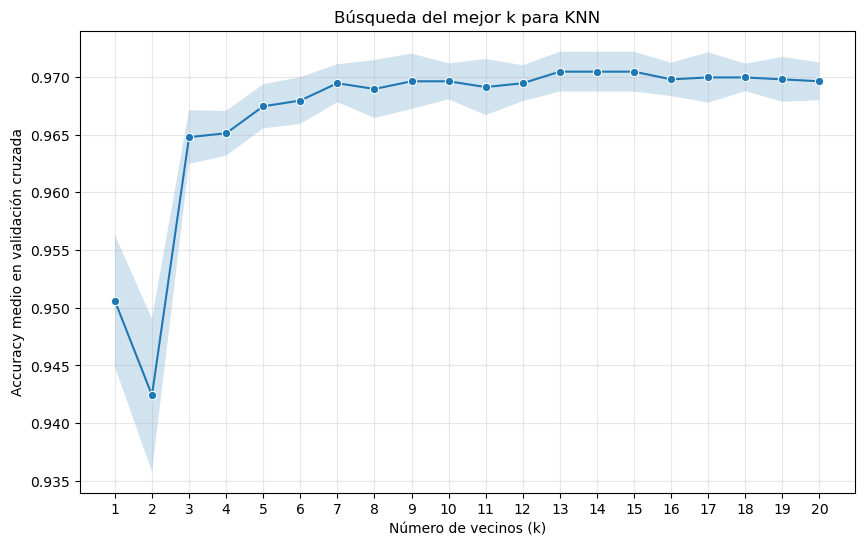

In [8]:
# Busco el mejor valor de k con validación cruzada
param_grid_knn = {
    "n_neighbors": list(range(1, 21))
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_projection, y_train)

print(f"Mejor valor de k: {grid_knn.best_params_['n_neighbors']}")
print(f"Mejor accuracy medio en validación cruzada: {grid_knn.best_score_:.4f}")

# Guardo los resultados de la búsqueda
resultados_knn = pd.DataFrame(grid_knn.cv_results_)
resultados_knn = resultados_knn[[
    "param_n_neighbors",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

resultados_knn = resultados_knn.rename(columns={
    "param_n_neighbors": "k",
    "mean_test_score": "mean_accuracy",
    "std_test_score": "std_accuracy",
    "rank_test_score": "rank"
})

resultados_knn["k"] = resultados_knn["k"].astype(int)
resultados_knn = resultados_knn.sort_values("k")

print("\nResultados de la búsqueda de hiperparámetro:")
print(resultados_knn)

# Represento la precisión media según k
plt.figure(figsize=(10, 6))
sns.lineplot(data=resultados_knn, x="k", y="mean_accuracy", marker="o")
plt.fill_between(
    resultados_knn["k"],
    resultados_knn["mean_accuracy"] - resultados_knn["std_accuracy"],
    resultados_knn["mean_accuracy"] + resultados_knn["std_accuracy"],
    alpha=0.2
)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy medio en validación cruzada")
plt.title("Búsqueda del mejor k para KNN")
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Sigue estos pasos con el dataset de entrenamiento (_train_):

1. Entrena un clasificador KNN utilizando el mejor hiperparámetro que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Este proceso te permitirá ver cómo el hiperparámetro óptimo que has identificado mejora la efectividad de tu modelo KNN en la clasificación de los datos.
</div>

Mejor valor de k: 13
Accuracy en train con el mejor k: 0.9715
Accuracy en test con el mejor k: 0.9686

Matriz de confusión en test:
[[212   4   2   2   5]
 [  0 107   0   0  12]
 [  1   2 154   0   0]
 [  6   0   0 287   1]
 [  1  10   1   0 692]]


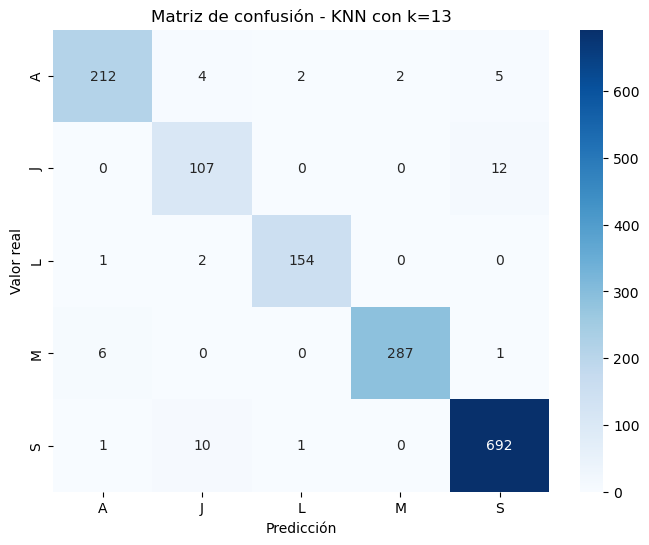

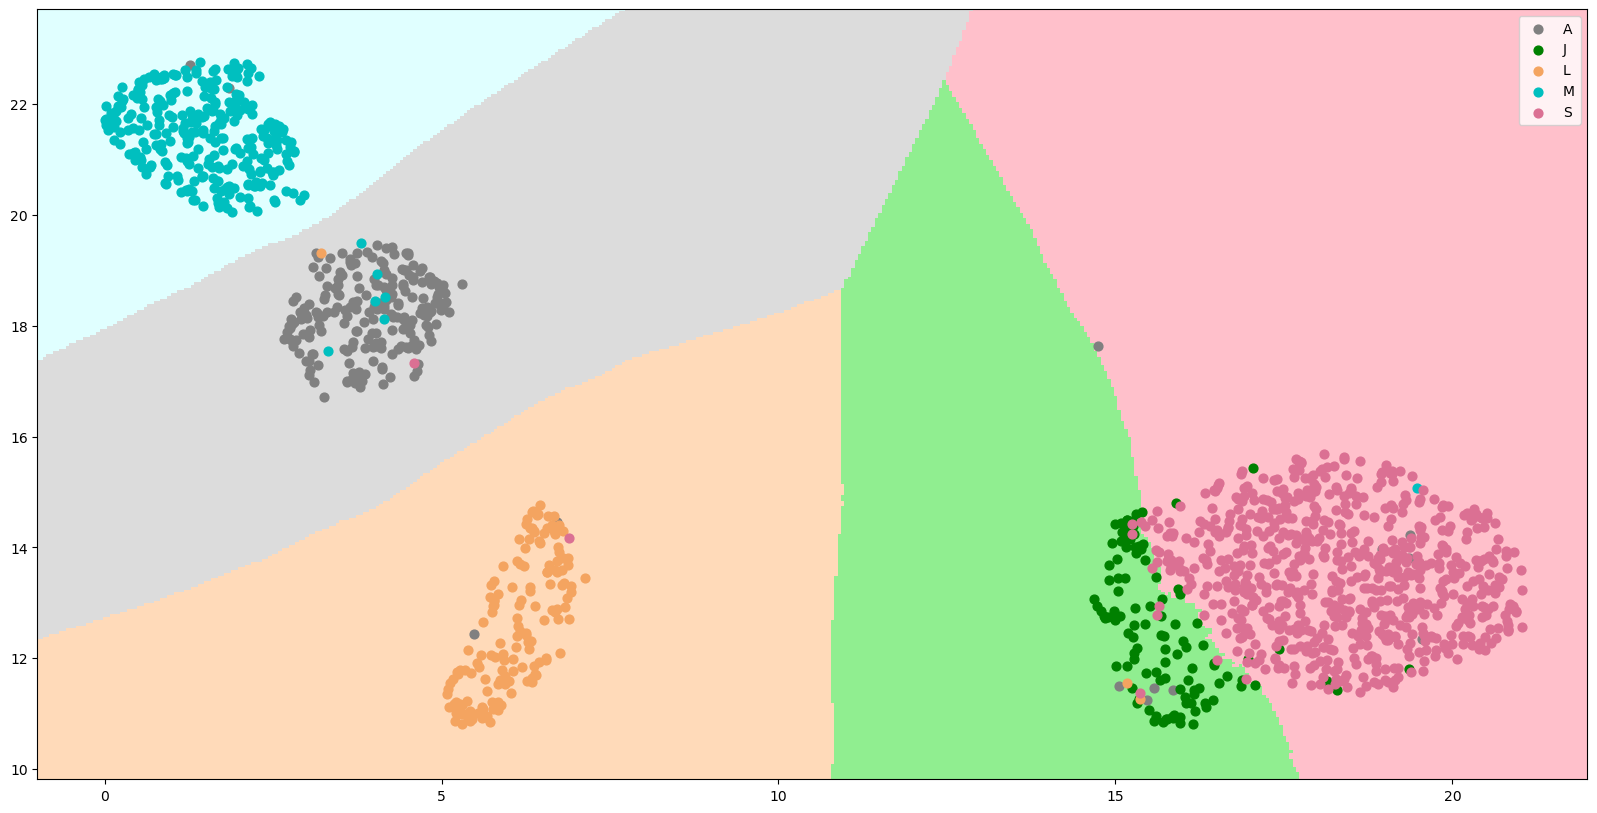

In [9]:
# Entreno el modelo KNN con el mejor valor de k encontrado
best_k = grid_knn.best_params_["n_neighbors"]

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_projection, y_train)

# Hago predicciones en train y test
y_train_pred_knn_best = knn_best.predict(X_train_projection)
y_test_pred_knn_best = knn_best.predict(X_test_projection)

# Calculo accuracy en train y test
acc_train_knn_best = accuracy_score(y_train, y_train_pred_knn_best)
acc_test_knn_best = accuracy_score(y_test, y_test_pred_knn_best)

print(f"Mejor valor de k: {best_k}")
print(f"Accuracy en train con el mejor k: {acc_train_knn_best:.4f}")
print(f"Accuracy en test con el mejor k: {acc_test_knn_best:.4f}")

# Calculo matriz de confusión en test
cm_knn_best = confusion_matrix(y_test, y_test_pred_knn_best)
print("\nMatriz de confusión en test:")
print(cm_knn_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_knn_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión - KNN con k={best_k}")
plt.show()

# Represento la frontera de decisión
plot_decision_boundaries(knn_best, X_test_projection, y_test)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Comenta los resultados obtenidos en la búsqueda del mejor hiperparámetro. Reflexiona sobre cómo varió el rendimiento del modelo con los diferentes valores de `n_neighbors`.
2. Analiza cómo se visualiza gráficamente el cambio del valor de `n_neighbors`. ¿Observas alguna tendencia o patrón claro? ¿Es coherente esta diferencia entre los dos gráficos al cambiar el parámetro?
3. Examina las fronteras de decisión que has generado. ¿La forma de estas fronteras tiene sentido dado el algoritmo KNN utilizado? Piensa en cómo la elección del número de vecinos influye en la forma de la frontera.
4. Evalúa las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son estas predicciones consistentes con lo que observas en las fronteras de decisión?

Este análisis te ayudará a comprender la eficacia del modelo KNN con diferentes configuraciones de `n_neighbors` y su impacto en la clasificación de los datos."
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En la búsqueda del mejor hiperparámetro observo que el rendimiento del modelo cambia bastante cuando `n_neighbors` toma valores muy pequeños, pero después tiende a estabilizarse. En general, veo que los valores más bajos ofrecen peores resultados que los valores intermedios, mientras que a partir de cierto punto la precisión se mantiene alta y con variaciones pequeñas. Esto me hace pensar que valores demasiado bajos hacen que el modelo sea más sensible a casos concretos del entrenamiento.

Gráficamente también aprecio una tendencia clara. Con un valor pequeño de `k`, la frontera de decisión es más irregular y aparecen zonas más estrechas y cambios bruscos entre regiones. En cambio, con el mejor valor encontrado en la búsqueda, la separación entre clases sigue siendo buena, pero la frontera resulta más suave y estable. En mi opinión, esta diferencia es coherente con el funcionamiento de KNN, porque al aumentar el número de vecinos la clasificación depende de un entorno más amplio y no tanto de puntos aislados.

Las fronteras de decisión que he obtenido sí tienen sentido para un algoritmo KNN. Como este método clasifica a partir de la cercanía entre observaciones, es normal que la frontera se adapte a la distribución local de los puntos. Precisamente por eso, cuando `k` es pequeño la frontera se vuelve más fragmentada, mientras que con un valor mayor se suaviza. En este caso, el modelo con el mejor `k` conserva bien la estructura general de los grupos y evita parte de la irregularidad que sí aparece con un valor pequeño.

Si comparo las predicciones sobre el conjunto de test, también veo una mejora clara al usar el mejor hiperparámetro encontrado. El modelo con un valor pequeño de `k` obtiene una precisión más alta en entrenamiento, pero generaliza peor en test. En cambio, con el mejor valor de `k` la precisión en test mejora y la diferencia entre train y test se reduce. Para mí, esto sugiere una mejor capacidad de generalización. Además, la matriz de confusión del modelo con el mejor `k` muestra menos errores en varias clases respecto al modelo inicial, lo que encaja con la frontera más estable que se observa en la representación gráfica.

En conjunto, concluyo que KNN funciona bien en este problema, pero su comportamiento depende claramente del valor de `n_neighbors`. En mis resultados, usar el mejor `k` encontrado ofrece un equilibrio mejor que usar un valor muy pequeño, porque reduce la sensibilidad a variaciones locales, mejora la precisión en test y genera fronteras de decisión más coherentes con la estructura global de los datos.

</div>

<a id='ej13'></a>
## 1.3. SVM (1.25 puntos)

En esta sección, vas a explorar las Máquinas de Vectores de Soporte (SVM), que se basan en el concepto del _Maximal Margin Classifier_ y el hiperplano.

Un hiperplano en un espacio p-dimensional se define como un subespacio plano y afín de dimensiones p-1. En dos dimensiones, es una recta; en tres, un plano convencional. Para dimensiones mayores a tres, aunque no es intuitivo visualizarlo, el concepto se mantiene.

Cuando los casos son perfectamente separables de manera lineal, surgen infinitos posibles hiperplanos. Para seleccionar el clasificador óptimo, utiliza el concepto de _maximal margin hyperplane_, el hiperplano que se encuentra más alejado de todas las observaciones de entrenamiento. Este se define calculando la distancia perpendicular mínima (margen) de las observaciones a un hiperplano. El hiperplano óptimo es aquel que maximiza este margen.

En el proceso de optimización, debes tener en cuenta que solo las observaciones al margen o que lo violan (vectores soporte) influyen en el hiperplano. Estos vectores soporte son los que definen el clasificador.

#### Los _kernels_ en SVM

En situaciones donde no puedes encontrar un hiperplano que separe dos clases, es decir, cuando las clases no son linealmente separables, puedes utilizar el truco del núcleo (_kernel trick_). Este método te permite trabajar en una dimensión nueva donde es posible encontrar un hiperplano para separar las clases.

Al igual que con el KNN, las SVM también dependen de varios hiperparámetros. En este caso, te enfocarás en optimizar dos hiperparámetros:

1. **C**: la regularización, que es el valor de penalización de los errores en la clasificación. Este valor indica el compromiso entre obtener el hiperplano con el margen más grande posible y clasificar correctamente el máximo número de ejemplos. Debes probar los siguientes valores: 0.01, 0.1, 1, 10, 50, 100 y 200.
   
2. **Gamma**: un coeficiente que multiplica la distancia entre dos puntos en el kernel radial. En términos simples, cuanto más pequeño sea gamma, más influencia tendrán dos puntos cercanos. Debes probar los valores: 0.001, 0.01, 0.1, 1 y 10.

Para validar el rendimiento del algoritmo con cada combinación de hiperparámetros, utiliza la validación cruzada (_cross-validation_) con 5 particiones estratificadas."

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>


1. Calcula el valor óptimo de los hiperparámetros _C_ y _gamma_ utilizando una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar los valores óptimos.
2. Para cada combinación de valores, calcula su promedio y la desviación estándar.
3. Haz un _heatmap_ para visualizar la precisión según los diferentes valores de los hiperparámetros.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador SVC (de `SVM` de `sklearn`). Para la visualización del _heatmap_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual los valores de _C_ y _gamma_ que maximizan la precisión de tu modelo SVM.
</div>

Mejor valor de C: 100
Mejor valor de gamma: 0.1
Mejor accuracy medio en validación cruzada: 0.9706

Resultados de la búsqueda de hiperparámetros:
         C   gamma  mean_accuracy  std_accuracy  rank
0     0.01   0.001       0.665054      0.000733    34
5     0.10   0.001       0.903204      0.001751    32
10    1.00   0.001       0.957609      0.002336    29
15   10.00   0.001       0.960781      0.001679    26
20   50.00   0.001       0.961448      0.002613    25
25  100.00   0.001       0.962283      0.001866    24
30  200.00   0.001       0.964285      0.001445    22
1     0.01   0.010       0.903204      0.001751    32
6     0.10   0.010       0.957943      0.002027    28
11    1.00   0.010       0.964786      0.000628    21
16   10.00   0.010       0.969458      0.002574    10
21   50.00   0.010       0.966288      0.002161    19
26  100.00   0.010       0.966622      0.001192    17
31  200.00   0.010       0.966789      0.001118    15
2     0.01   0.100       0.950934      0.001

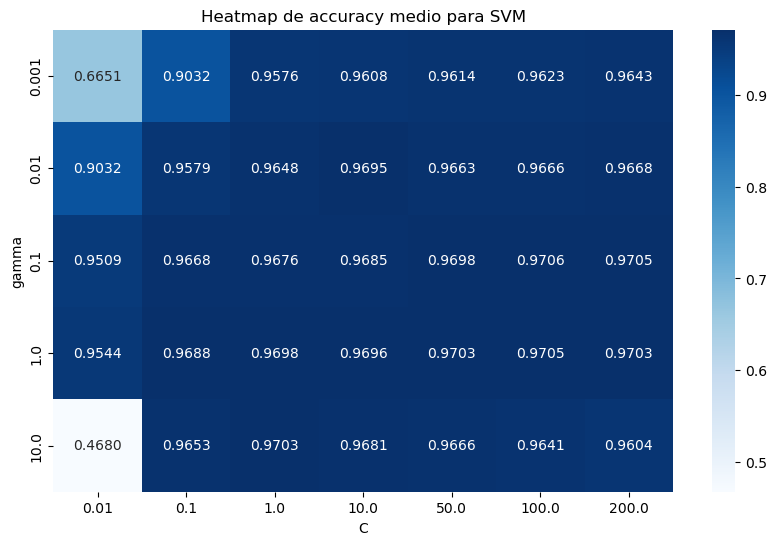

In [10]:
# Busco los mejores hiperparámetros de SVM con validación cruzada
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10, 50, 100, 200],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_projection, y_train)

print(f"Mejor valor de C: {grid_svm.best_params_['C']}")
print(f"Mejor valor de gamma: {grid_svm.best_params_['gamma']}")
print(f"Mejor accuracy medio en validación cruzada: {grid_svm.best_score_:.4f}")

# Guardo los resultados de la búsqueda
resultados_svm = pd.DataFrame(grid_svm.cv_results_)
resultados_svm = resultados_svm[[
    "param_C",
    "param_gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

resultados_svm = resultados_svm.rename(columns={
    "param_C": "C",
    "param_gamma": "gamma",
    "mean_test_score": "mean_accuracy",
    "std_test_score": "std_accuracy",
    "rank_test_score": "rank"
})

resultados_svm["C"] = resultados_svm["C"].astype(float)
resultados_svm["gamma"] = resultados_svm["gamma"].astype(float)
resultados_svm = resultados_svm.sort_values(["gamma", "C"])

print("\nResultados de la búsqueda de hiperparámetros:")
print(resultados_svm)

# Se construye el heatmap con la precisión media
tabla_heatmap_svm = resultados_svm.pivot(
    index="gamma",
    columns="C",
    values="mean_accuracy"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    tabla_heatmap_svm,
    annot=True,
    fmt=".4f",
    cmap="Blues"
)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("Heatmap de accuracy medio para SVM")
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Realiza los siguientes pasos con el dataset de entrenamiento (_train_):

1. Entrena un modelo SVM utilizando la mejor combinación de parámetros que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Este proceso te permitirá ver cómo la mejor combinación de parámetros mejora la efectividad de tu modelo SVM en la clasificación de los datos.
</div>

Mejor valor de C: 100
Mejor valor de gamma: 0.1
Accuracy en train con la mejor SVM: 0.9708
Accuracy en test con la mejor SVM: 0.9706

Matriz de confusión en test:
[[212   5   2   2   4]
 [  0 109   0   0  10]
 [  1   2 154   0   0]
 [  6   0   0 287   1]
 [  1   9   1   0 693]]


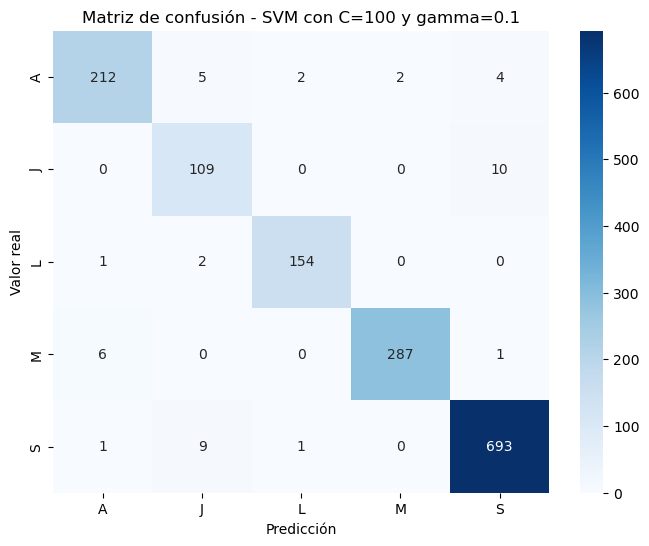

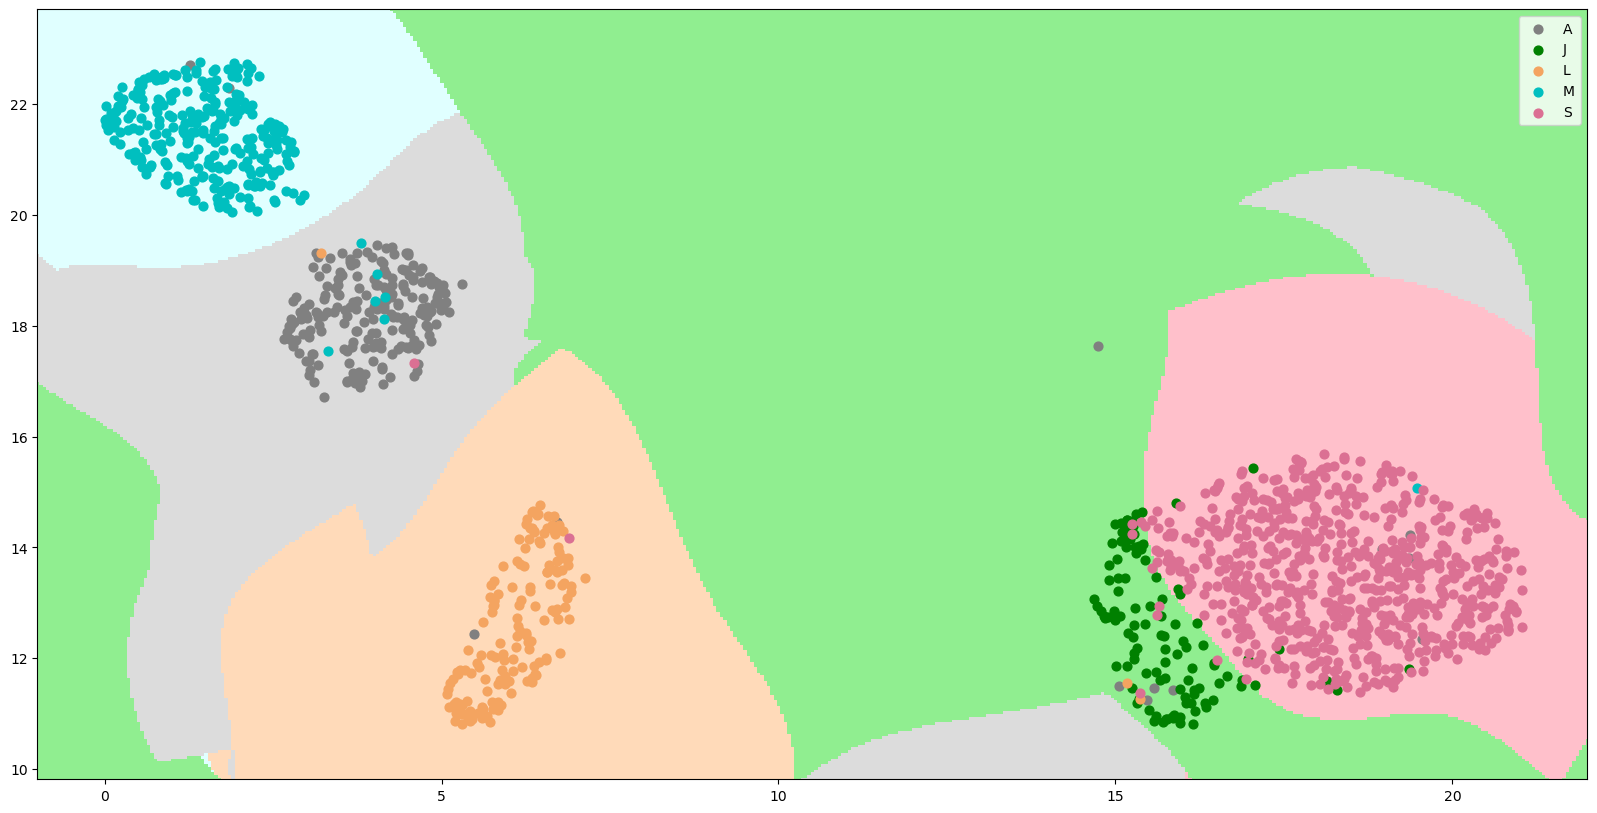

In [11]:
# Entreno el modelo SVM con los mejores hiperparámetros encontrados
best_c = grid_svm.best_params_["C"]
best_gamma = grid_svm.best_params_["gamma"]

svm_best = SVC(
    C=best_c,
    gamma=best_gamma,
    kernel="rbf"
)

svm_best.fit(X_train_projection, y_train)

# Hago predicciones en train y test
y_train_pred_svm = svm_best.predict(X_train_projection)
y_test_pred_svm = svm_best.predict(X_test_projection)

# Calculo accuracy en train y test
acc_train_svm = accuracy_score(y_train, y_train_pred_svm)
acc_test_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"Mejor valor de C: {best_c}")
print(f"Mejor valor de gamma: {best_gamma}")
print(f"Accuracy en train con la mejor SVM: {acc_train_svm:.4f}")
print(f"Accuracy en test con la mejor SVM: {acc_test_svm:.4f}")

# Calculo la matriz de confusión en test
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
print("\nMatriz de confusión en test:")
print(cm_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión - SVM con C={best_c} y gamma={best_gamma}")
plt.show()

# Visualizo la frontera de decisión
plot_decision_boundaries(svm_best, X_test_projection, y_test)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Comenta los resultados obtenidos en la búsqueda de los mejores hiperparámetros. Reflexiona sobre cómo varió el rendimiento del modelo SVM con los diferentes valores de _C_ y _gamma_. Considera si los valores óptimos encontrados tienen sentido en el contexto de tu conjunto de datos.
2. Examina las fronteras de decisión que has generado con el modelo SVM. ¿La forma de estas fronteras es coherente con lo que esperarías del algoritmo utilizado? Piensa en cómo la combinación de hiperparámetros seleccionados podría influir en la forma de las fronteras.
3. Evalúa las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son estas predicciones consistentes con lo que observas en las fronteras de decisión?

Este análisis te ayudará a comprender la eficacia del modelo SVM con los hiperparámetros seleccionados y su impacto en la clasificación de los datos."
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En la búsqueda de hiperparámetros observo que el rendimiento del modelo SVM varía de forma clara según la combinación de `C` y `gamma`. En general, veo que muchas combinaciones ofrecen resultados altos y bastante próximos entre sí, pero también se aprecia que algunas elecciones funcionan claramente peor. Esto me hace pensar que el ajuste de estos dos hiperparámetros es importante, porque no cualquier combinación permite separar bien las clases.

En mi opinión, los valores óptimos encontrados tienen sentido en el contexto de este conjunto de datos. Como estamos trabajando con una proyección bidimensional en la que las clases no quedan separadas de forma completamente lineal, es razonable que el mejor modelo sea una SVM con kernel radial. Además, la mejor combinación aparece asociada a valores que permiten una frontera flexible, pero sin que el modelo se vuelva excesivamente inestable.

Las fronteras de decisión que se obtienen con este modelo son coherentes con lo que esperaría de una SVM con kernel RBF. No aparecen únicamente regiones separadas por rectas, sino fronteras curvas y zonas cerradas alrededor de algunos grupos. Esto encaja con la idea del truco del kernel, ya que permite construir separaciones no lineales. En la representación gráfica veo que las clases más compactas quedan bastante bien delimitadas, mientras que en las zonas donde hay más proximidad entre clases aparecen fronteras más complejas.

Las predicciones sobre el conjunto de test también son consistentes con lo que muestran las fronteras. La precisión es alta tanto en entrenamiento como en test, y la diferencia entre ambos conjuntos es pequeña. Esto me hace pensar que el ajuste es bueno y que no hay una señal clara de sobreajuste. Además, la matriz de confusión muestra que la mayor parte de observaciones se clasifica correctamente, con pocos errores fuera de la diagonal principal. Los fallos aparecen sobre todo en clases cercanas entre sí, lo cual también es coherente con las zonas donde visualmente las clases están más próximas o donde la frontera resulta más ajustada.

En conjunto, concluyo que la SVM funciona muy bien en este problema. La búsqueda de hiperparámetros ha sido importante porque no todas las combinaciones de `C` y `gamma` dan el mismo resultado, y los valores seleccionados permiten obtener una precisión muy alta junto con unas fronteras de decisión coherentes con la estructura de los datos.

</div>

<a id='ej14'></a>
## 1.4. Árboles de decisión (1.25 puntos)

En esta sección, vas a explorar los árboles de decisión, modelos predictivos que se basan en reglas binarias (si/no) para clasificar las observaciones según sus atributos y predecir el valor de la variable respuesta. Estos árboles pueden ser clasificadores, como en tu ejemplo, o regresores para predecir variables continuas.

#### Construcción de un Árbol

Para construir un árbol, sigue el algoritmo de *recursive binary splitting*:

1. Comienza en la parte superior del árbol, donde todas las observaciones pertenecen a la misma región.
2. Identifica todos los posibles puntos de corte para cada uno de los predictores. Estos puntos de corte son los diferentes niveles de los predictores.
3. Evalúa las posibles divisiones para cada predictor utilizando una medida específica. En los clasificadores, estas medidas pueden ser el *classification error rate*, el índice Gini, la entropía o el chi-square.

Comprender estos pasos te ayudará a entender cómo los árboles de decisión crean divisiones binarias para clasificar los datos y cómo estos pueden aplicarse tanto para clasificación como para regresión.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Sigue estos pasos:

1. Con el dataset de entrenamiento, entrena un árbol de decisión utilizando el clasificador `DecisionTreeClassifier` de la biblioteca `tree` de `sklearn`.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.
5. Representa el árbol de decisión. Puedes utilizar el comando `plot.tree` de la biblioteca `tree` de `sklearn`.

Estos pasos te permitirán evaluar cómo el árbol de decisión se comporta en tu conjunto de datos, tanto en términos de clasificación como en su representación visual."
</div>

Accuracy en train del árbol base: 1.0000
Accuracy en test del árbol base: 0.9460

Matriz de confusión en test:
[[209   4   2   6   4]
 [  2 101   1   0  15]
 [  3   2 150   1   1]
 [ 16   1   0 276   1]
 [  1  19   1   1 682]]


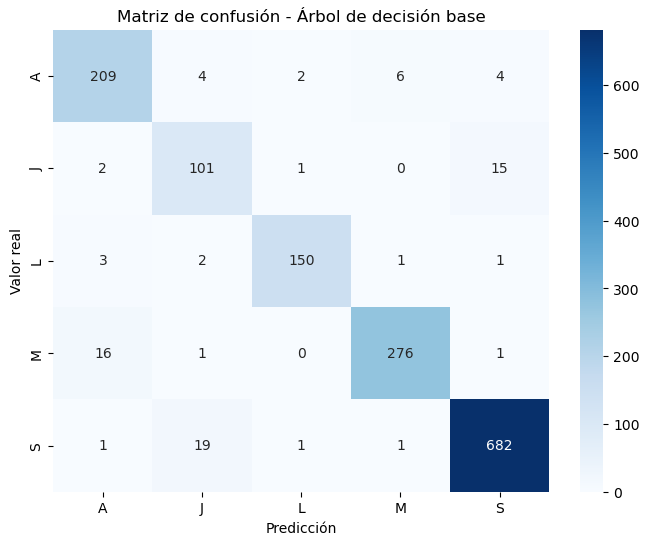

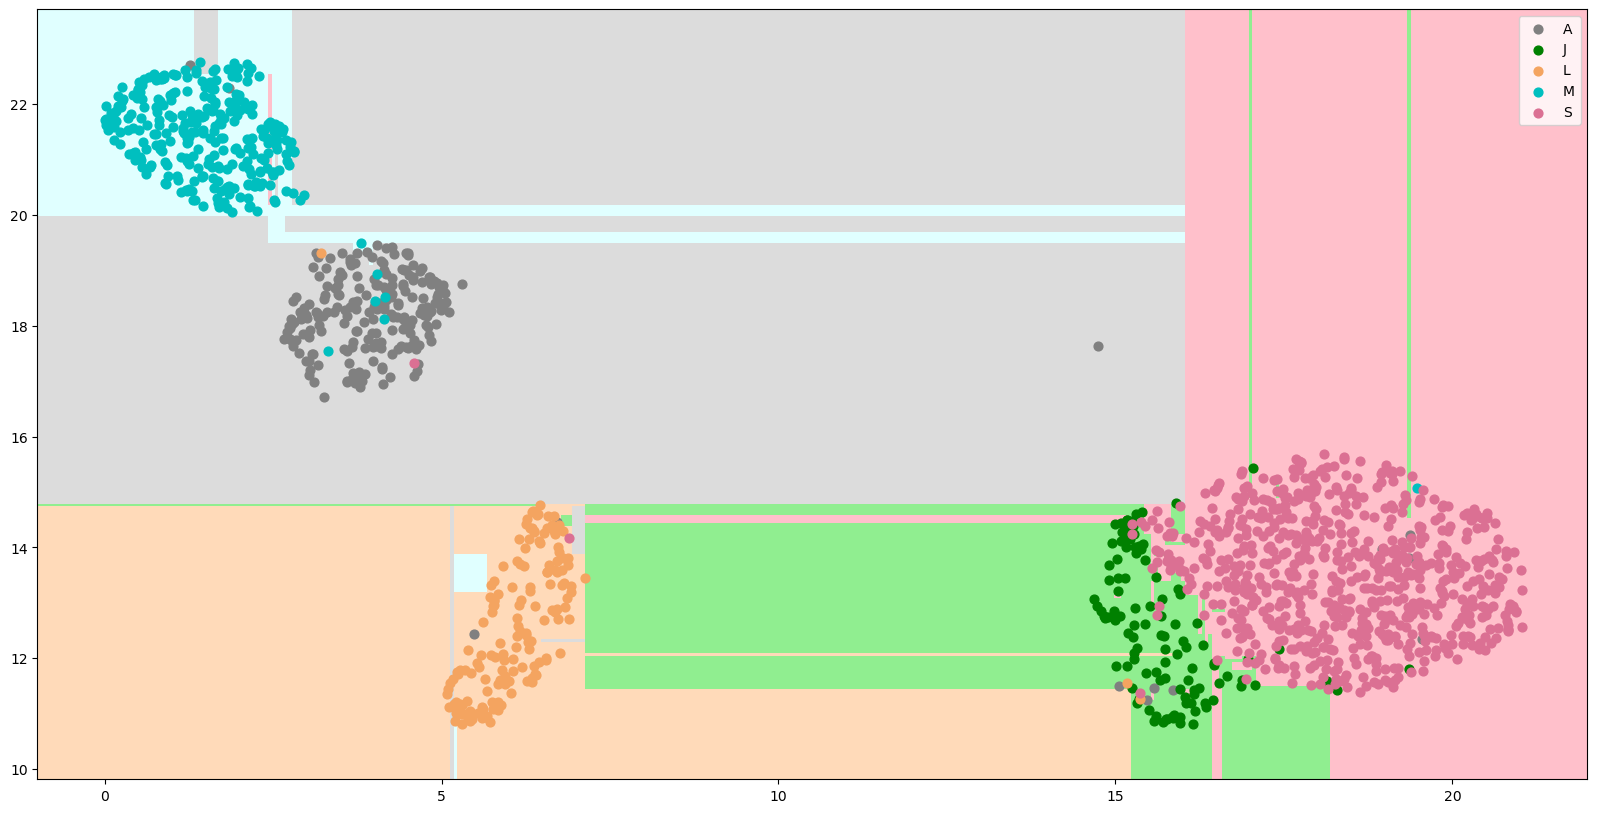

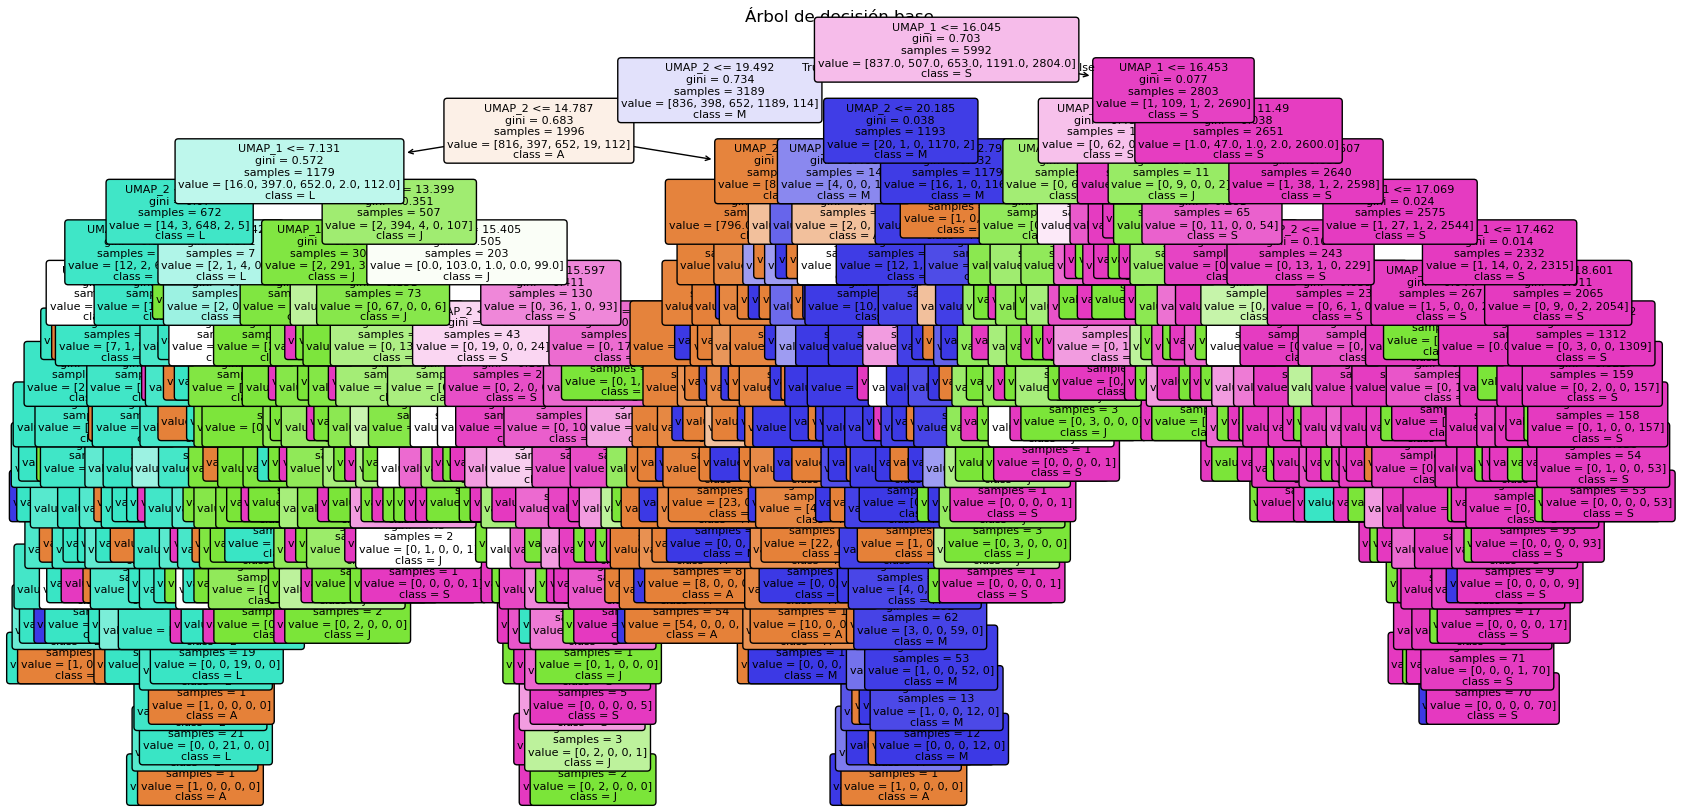

In [12]:
# Entreno un árbol de decisión sin ajustar hiperparámetros
arbol_base = DecisionTreeClassifier(random_state=24)
arbol_base.fit(X_train_projection, y_train)

# Hago predicciones en train y test
y_train_pred_arbol_base = arbol_base.predict(X_train_projection)
y_test_pred_arbol_base = arbol_base.predict(X_test_projection)

# Calculo accuracy en train y test
acc_train_arbol_base = accuracy_score(y_train, y_train_pred_arbol_base)
acc_test_arbol_base = accuracy_score(y_test, y_test_pred_arbol_base)

print(f"Accuracy en train del árbol base: {acc_train_arbol_base:.4f}")
print(f"Accuracy en test del árbol base: {acc_test_arbol_base:.4f}")

# Calculo matriz de confusión en test
cm_arbol_base = confusion_matrix(y_test, y_test_pred_arbol_base)
print("\nMatriz de confusión en test:")
print(cm_arbol_base)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_arbol_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Árbol de decisión base")
plt.show()

# Represento la frontera de decisión
plot_decision_boundaries(arbol_base, X_test_projection, y_test)

# Represento el árbol de decisión
plt.figure(figsize=(20, 10))
tree.plot_tree(
    arbol_base,
    feature_names=["UMAP_1", "UMAP_2"],
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión base")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Evalúa y comenta los resultados obtenidos con el árbol de decisión. Considera tanto el _accuracy_ del modelo en los conjuntos de _train_ y _test_ como los resultados de la matriz de confusión.
2. Reflexiona sobre cómo la frontera de decisión visualizada en el conjunto de _test_ se alinea con los resultados obtenidos. ¿Es coherente con lo que esperarías de un árbol de decisión?
3. Observa la representación gráfica del árbol. Analiza cómo las diferentes ramificaciones y decisiones tomadas en el árbol explican el comportamiento del modelo y su impacto en la clasificación de los datos.

Este análisis te ayudará a comprender en profundidad el funcionamiento y la eficacia del árbol de decisión en tu conjunto de datos específico.

</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En el árbol de decisión base observo un comportamiento claro de sobreajuste. El modelo ajusta extremadamente bien los datos de entrenamiento, pero su rendimiento baja en test. Para mí, esta diferencia indica que el árbol se ha adaptado demasiado a los datos de entrenamiento y que no generaliza tan bien cuando trabaja con observaciones no vistas. La matriz de confusión confirma que, aunque el rendimiento sigue siendo bueno, hay varios errores concentrados en algunas clases, especialmente entre clases cercanas entre sí.

La frontera de decisión también me parece coherente con ese comportamiento. Visualmente se observan regiones rectangulares muy marcadas, con cortes horizontales y verticales, que es justo lo que esperaría de un árbol de decisión. Además, aparecen zonas bastante fragmentadas y algunas bandas estrechas, lo que sugiere que el modelo está haciendo particiones muy específicas para adaptarse al entrenamiento. En mi opinión, esto encaja con la idea de que el árbol termina creando muchas divisiones para separar al máximo las observaciones conocidas.

La representación del árbol también refuerza esta idea. Se ve un árbol muy grande, con muchas ramificaciones y una profundidad elevada, lo que hace más difícil interpretarlo de forma global. Aun así, sí permite entender por qué el modelo produce fronteras escalonadas: cada nodo introduce una nueva condición binaria sobre una de las dos variables proyectadas por UMAP, y el resultado final es una partición del plano en regiones rectangulares. En conjunto, yo diría que este árbol clasifica razonablemente bien, pero lo hace con una complejidad demasiado alta, y eso explica que aparezca sobreajuste.

</div>

#### Evitando el *overfitting*

El proceso de construcción de árboles descrito tiende a reducir rápidamente el error de entrenamiento, por lo que generalmente el modelo se ajusta muy bien a las observaciones utilizadas como entrenamiento (conjunto de *train*). Como consecuencia, los árboles de decisión tienden al *overfitting*.
   
Para evitar el *overfitting* en los árboles de decisión, es crucial que modifiques ciertos hiperparámetros del modelo de la siguiente manera:

1. Utiliza el hiperparámetro `max_depth`, que define la profundidad máxima del árbol. Deberás explorar los valores entre 4 y 10 para encontrar el equilibrio adecuado entre la complejidad del modelo y su capacidad para generalizar.
2. Establece el hiperparámetro `min_samples_split`, que es el número mínimo de observaciones que debe tener una hoja del árbol antes de considerar una división. Experimenta con valores como 2, 10, 20, 50 y 100 para asegurarte de que el árbol no se vuelva demasiado específico para las observaciones de entrenamiento.

Ajustando estos hiperparámetros, podrás controlar la tendencia del árbol de decisión a sobreajustarse al conjunto de entrenamiento, mejorando así su capacidad para realizar predicciones efectivas en nuevos datos."

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>

1. Calcula el valor óptimo de los hiperparámetros `max_depth` y `min_samples_split` utilizando una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar los valores óptimos que evitarán el sobreajuste.
2. Para cada combinación de valores, calcula su promedio y la desviación estándar.
3. Haz un _heatmap_ para visualizar la precisión según los diferentes valores de los hiperparámetros.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador `DecisionTreeClassifier` de `tree` de `sklearn`. Para la visualización del _heatmap_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual los valores de `max_depth` y `min_samples_split` que maximizan la precisión de tu árbol de decisión, minimizando el riesgo de sobreajuste.
</div>

Mejor valor de max_depth: 6
Mejor valor de min_samples_split: 50
Mejor accuracy medio en validación cruzada: 0.9661

Resultados de la búsqueda de hiperparámetros:
    max_depth  min_samples_split  mean_accuracy  std_accuracy  rank
0           4                  2       0.956442      0.003232    27
1           4                 10       0.956442      0.002962    28
2           4                 20       0.956942      0.003019    24
3           4                 50       0.956942      0.003019    24
4           4                100       0.955607      0.003239    34
5           5                  2       0.956274      0.002836    30
6           5                 10       0.956274      0.002409    29
7           5                 20       0.956942      0.002735    26
8           5                 50       0.957276      0.002774    23
9           5                100       0.955940      0.005056    32
10          6                  2       0.963784      0.002832     6
11          6        

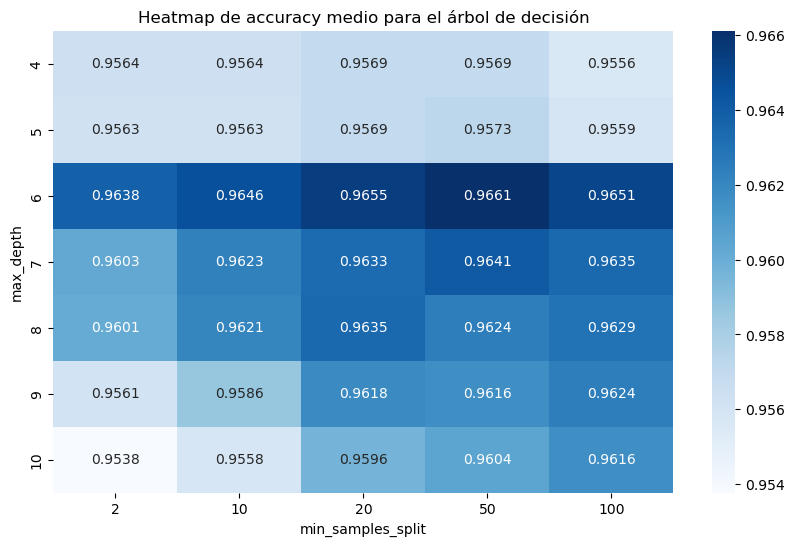

In [13]:
# Busco los mejores hiperparámetros para evitar overfitting
param_grid_arbol = {
    "max_depth": list(range(4, 11)),
    "min_samples_split": [2, 10, 20, 50, 100]
}

grid_arbol = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=24),
    param_grid=param_grid_arbol,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_arbol.fit(X_train_projection, y_train)

print(f"Mejor valor de max_depth: {grid_arbol.best_params_['max_depth']}")
print(f"Mejor valor de min_samples_split: {grid_arbol.best_params_['min_samples_split']}")
print(f"Mejor accuracy medio en validación cruzada: {grid_arbol.best_score_:.4f}")

# Guardo los resultados de la búsqueda
resultados_arbol = pd.DataFrame(grid_arbol.cv_results_)
resultados_arbol = resultados_arbol[[
    "param_max_depth",
    "param_min_samples_split",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

resultados_arbol = resultados_arbol.rename(columns={
    "param_max_depth": "max_depth",
    "param_min_samples_split": "min_samples_split",
    "mean_test_score": "mean_accuracy",
    "std_test_score": "std_accuracy",
    "rank_test_score": "rank"
})

resultados_arbol["max_depth"] = resultados_arbol["max_depth"].astype(int)
resultados_arbol["min_samples_split"] = resultados_arbol["min_samples_split"].astype(int)
resultados_arbol = resultados_arbol.sort_values(["max_depth", "min_samples_split"])

print("\nResultados de la búsqueda de hiperparámetros:")
print(resultados_arbol)

# Construyo el heatmap con la precisión media
tabla_heatmap_arbol = resultados_arbol.pivot(
    index="max_depth",
    columns="min_samples_split",
    values="mean_accuracy"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    tabla_heatmap_arbol,
    annot=True,
    fmt=".4f",
    cmap="Blues"
)
plt.xlabel("min_samples_split")
plt.ylabel("max_depth")
plt.title("Heatmap de accuracy medio para el árbol de decisión")
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>


1. Entrena un árbol de decisión con el dataset de entrenamiento (_train_) utilizando la mejor combinación de parámetros que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.
5. Representa el árbol de decisión.

Estos pasos te permitirán evaluar cómo el árbol de decisión, ajustado con los hiperparámetros óptimos, se comporta en tu conjunto de datos, tanto en términos de clasificación como en su representación visual."
    
</div>

Mejor valor de max_depth: 6
Mejor valor de min_samples_split: 50
Accuracy en train del árbol ajustado: 0.9713
Accuracy en test del árbol ajustado: 0.9626

Matriz de confusión en test:
[[213   4   2   2   4]
 [  1 109   0   0   9]
 [  5   2 150   0   0]
 [ 11   0   0 282   1]
 [  1  13   1   0 689]]


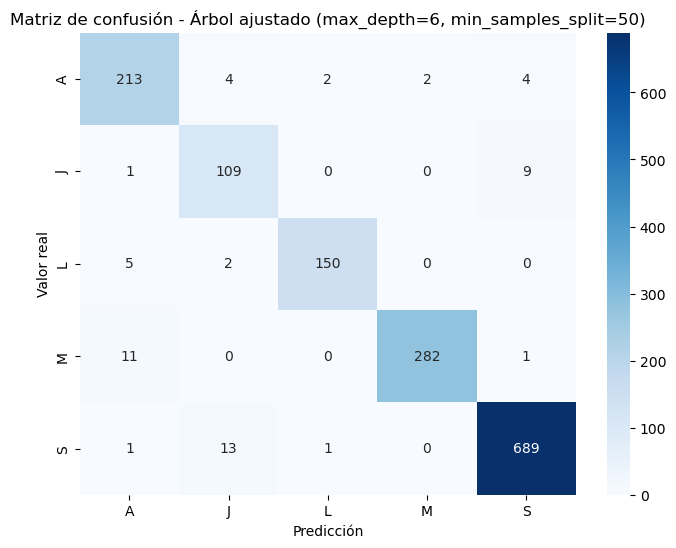

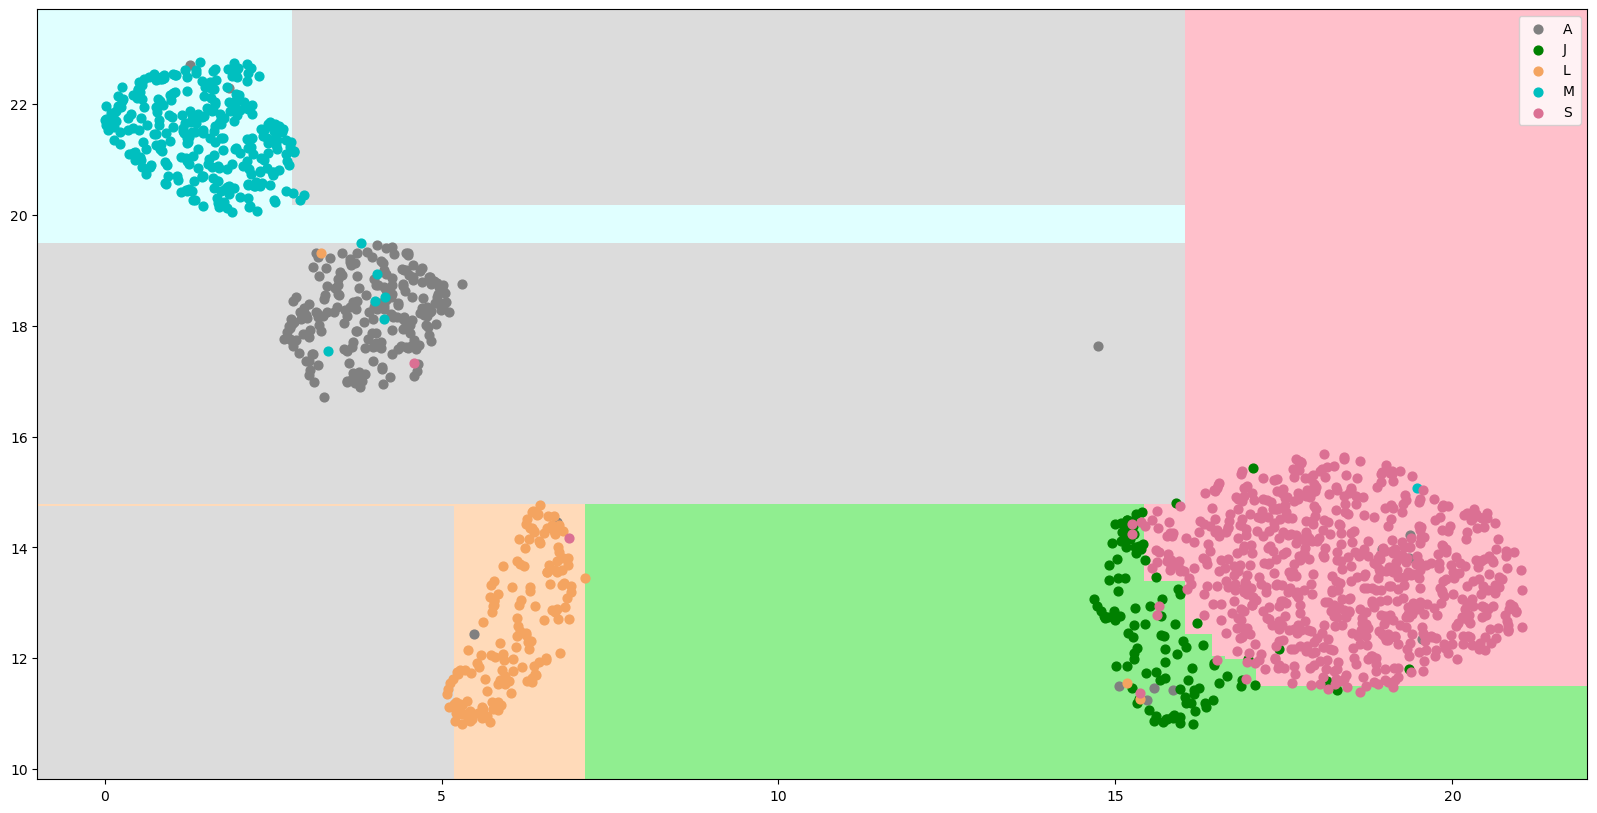

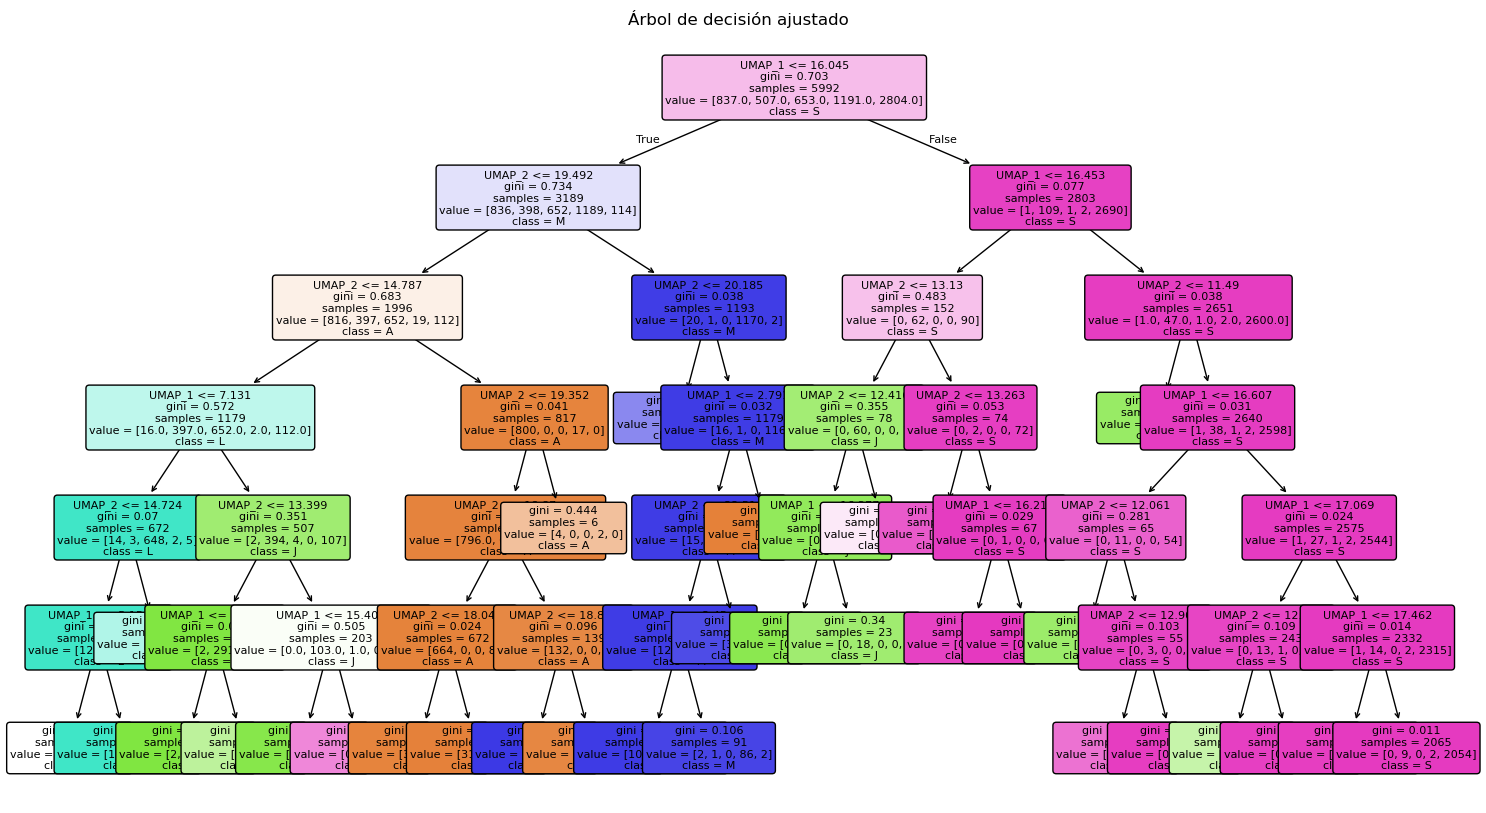

In [14]:
# Entreno el árbol de decisión con los mejores hiperparámetros
best_max_depth = grid_arbol.best_params_["max_depth"]
best_min_samples_split = grid_arbol.best_params_["min_samples_split"]

arbol_ajustado = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    random_state=24
)

arbol_ajustado.fit(X_train_projection, y_train)

# Hago predicciones en train y test
y_train_pred_arbol_ajustado = arbol_ajustado.predict(X_train_projection)
y_test_pred_arbol_ajustado = arbol_ajustado.predict(X_test_projection)

# Calculo accuracy en train y test
acc_train_arbol_ajustado = accuracy_score(y_train, y_train_pred_arbol_ajustado)
acc_test_arbol_ajustado = accuracy_score(y_test, y_test_pred_arbol_ajustado)

print(f"Mejor valor de max_depth: {best_max_depth}")
print(f"Mejor valor de min_samples_split: {best_min_samples_split}")
print(f"Accuracy en train del árbol ajustado: {acc_train_arbol_ajustado:.4f}")
print(f"Accuracy en test del árbol ajustado: {acc_test_arbol_ajustado:.4f}")

# Calculo matriz de confusión en test
cm_arbol_ajustado = confusion_matrix(y_test, y_test_pred_arbol_ajustado)
print("\nMatriz de confusión en test:")
print(cm_arbol_ajustado)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_arbol_ajustado,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(
    f"Matriz de confusión - Árbol ajustado (max_depth={best_max_depth}, "
    f"min_samples_split={best_min_samples_split})"
)
plt.show()

# Represento la frontera de decisión
plot_decision_boundaries(arbol_ajustado, X_test_projection, y_test)

# Represento el árbol ajustado
plt.figure(figsize=(18, 10))
tree.plot_tree(
    arbol_ajustado,
    feature_names=["UMAP_1", "UMAP_2"],
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión ajustado")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Evalúa y comenta los resultados obtenidos en la búsqueda de los mejores hiperparámetros. Considera cómo la combinación óptima de `max_depth` y `min_samples_split` ha impactado el rendimiento del árbol de decisión.
2. Examina las fronteras de decisión generadas con el conjunto de _test_. Reflexiona sobre si la forma de estas fronteras es coherente con lo que esperarías de un árbol de decisión configurado con estos hiperparámetros.
3. Analiza las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son consistentes estas predicciones con la estructura del árbol de decisión y las fronteras observadas?

Este análisis te ayudará a comprender la eficacia del árbol de decisión con los hiperparámetros seleccionados y su impacto en la clasificación de los datos.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En la búsqueda de hiperparámetros observo que las mejores combinaciones se concentran en profundidades bajas y con valores de `min_samples_split` que evitan que el árbol crezca demasiado. En mi opinión, esto tiene sentido, porque limitar la profundidad y exigir un número mínimo mayor de observaciones para dividir reduce el riesgo de que el modelo aprenda particiones demasiado específicas.

Comparando este árbol ajustado con el árbol base, veo una mejora clara en la generalización. El árbol ajustado pierde parte del ajuste perfecto que tenía el árbol inicial sobre entrenamiento, pero a cambio mejora su comportamiento en test. Para mí, esto es una señal de que el modelo está más equilibrado: deja de adaptarse tanto al entrenamiento y gana capacidad para clasificar mejor datos nuevos. Además, la matriz de confusión sigue siendo muy buena y los errores quedan más controlados, aunque todavía aparecen algunas confusiones en clases cercanas.

Las fronteras de decisión generadas con este árbol ajustado me parecen más coherentes que las del árbol inicial. Siguen teniendo la forma rectangular típica de un árbol de decisión, pero ahora son mucho más simples y limpias. Ya no se ven tantas divisiones pequeñas ni bandas estrechas, sino regiones amplias que separan bastante bien los grupos principales. Eso me parece consistente con el hecho de haber reducido la profundidad del árbol y haber exigido un número mínimo mayor de observaciones para dividir.

La representación del árbol ajustado también resulta mucho más interpretable. En este caso sí se puede seguir con cierta claridad la lógica general del modelo: primero separa grandes regiones del espacio y después realiza algunas divisiones adicionales para refinar la clasificación. En conjunto, considero que este árbol ajustado funciona mejor que el árbol base, porque mantiene una precisión alta, reduce el sobreajuste y además ofrece una estructura más fácil de interpretar.

</div>

<a id='ej2'></a>
# 2. Implementación del caso práctico (5 puntos)

En este apartado vamos a trabajar con un conjunto de datos real para poner a prueba nuestros conocimientos.

<a id='ej21'></a>
## 2.1. Carga de datos (0.5 puntos)

El conjunto de datos <i>Vehicle Dataset from CarDekho</i>, disponible en [Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho), es un dataset tabular que recoge información sobre vehículos de segunda mano obtenida de plataformas de compraventa online. Su objetivo principal es servir como base para tareas de análisis de datos y aprendizaje automático, especialmente en problemas de regresión como la predicción de precios de coches usados.

Este dataset incluye variables relevantes como el nombre del vehículo, año de fabricación, precio de venta, kilómetros recorridos, tipo de combustible, tipo de vendedor, transmisión y número de propietarios anteriores. Gracias a esta combinación de características, permite estudiar cómo distintos factores influyen en el valor de mercado de un automóvil, siendo muy utilizado en ejercicios educativos y proyectos de machine learning enfocados en modelado predictivo y análisis exploratorio de datos.

En primer lugar, cargaremos el conjunto de datos y nos aseguraremos de que no tenga valores nulos.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Carga el conjunto de datos desde el fichero `Car details v3.csv`.
2. Échale un vistazo a las columnas resultantes del Dataframe.
3. Quédate con las variables que consideres oportuna y transforma las que necesites transformar para hacerlas más manejables
4. Imputa los valores que no vengan en caso de hacer falta.

</div>

In [15]:
# Cargo el dataset
datos_coches: pd.DataFrame = pd.read_csv("Car details v3.csv")

print(f"número de filas inicial: {datos_coches.shape[0]}")
print(f"número de columnas inicial: {datos_coches.shape[1]}")

# Miro las columnas disponibles
print("\ncolumnas originales:")
print(datos_coches.columns.tolist())

# Hago una copia de trabajo
df_coches: pd.DataFrame = datos_coches.copy()

# Creo una variable más manejable a partir del nombre
df_coches["marca"] = df_coches["name"].str.split().str[0]

# Transformo variables de texto a formato numérico simple
df_coches["mileage"] = df_coches["mileage"].str.extract(r"([0-9]+\.?[0-9]*)").astype(float)
df_coches["engine"] = df_coches["engine"].str.extract(r"([0-9]+\.?[0-9]*)").astype(float)
df_coches["max_power"] = df_coches["max_power"].str.extract(r"([0-9]+\.?[0-9]*)").astype(float)

# Selecciono las variables con las que me voy a quedar
columnas_utiles: list[str] = [
    "year",
    "selling_price",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "marca"
]

df_coches = df_coches[columnas_utiles].copy()

# Compruebo valores nulos antes de imputar
print("\nvalores nulos antes de imputar:")
print(df_coches.isna().sum())

# Imputo valores nulos en variables numéricas con la mediana
columnas_numericas: list[str] = [
    "year",
    "selling_price",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

for columna in columnas_numericas:
    df_coches[columna] = df_coches[columna].fillna(df_coches[columna].median())

# Imputo valores nulos en variables categóricas con la moda
columnas_categoricas: list[str] = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "marca"
]

for columna in columnas_categoricas:
    df_coches[columna] = df_coches[columna].fillna(df_coches[columna].mode()[0])

# Compruebo que ya no quedan nulos
print("\nvalores nulos después de imputar:")
print(df_coches.isna().sum())

# Muestro una vista general del dataframe resultante
print(f"\ndimensiones finales: {df_coches.shape}")
display(df_coches.head())

número de filas inicial: 8128
número de columnas inicial: 13

columnas originales:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

valores nulos antes de imputar:
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
seats            221
marca              0
dtype: int64

valores nulos después de imputar:
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
marca            0
dtype: int64

dimensiones finales: (8128, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,marca
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,Maruti


<a id='ej22'></a>
## 2.2. Análisis estadístico básico y exploratorio de datos (1.5 puntos)

En esta sección trataremos de comprender cómo es el dato con el que vamos a trabajar. Qué mejor forma de hacerlo, como primera toma de contacto, que realizar un análsis estadístico básico y exploratorio de los datos tal y como hemos realizado en otras actividades previas.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>
realiza el análisis estadístico básico y el exploratorio de los datos.

</div>

In [16]:
# Miro la estructura general del dataframe
print(f"dimensiones del dataframe: {df_coches.shape}")
print("\ntipos de datos:")
print(df_coches.dtypes)

# Obtengo un resumen estadístico de las variables numéricas
resumen_numerico: pd.DataFrame = df_coches.describe().T
print("\nresumen estadístico de variables numéricas:")
display(resumen_numerico)

# Obtengo un resumen de las variables categóricas
resumen_categorico: pd.DataFrame = df_coches.describe(include="object").T
print("\nresumen de variables categóricas:")
display(resumen_categorico)

# Miro la distribución de frecuencias de algunas variables categóricas
print("\nfrecuencias de fuel:")
print(df_coches["fuel"].value_counts())

print("\nfrecuencias de seller_type:")
print(df_coches["seller_type"].value_counts())

print("\nfrecuencias de transmission:")
print(df_coches["transmission"].value_counts())

print("\nfrecuencias de owner:")
print(df_coches["owner"].value_counts())

dimensiones del dataframe: (8128, 12)

tipos de datos:
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
marca             object
dtype: object

resumen estadístico de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0000,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0000,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0000,2360457.0
mileage,8128.0,19.415554,3.981922,0.0,16.8,19.3,22.2775,42.0
engine,8128.0,1452.898130,498.196720,624.0,1197.0,1248.0,1582.0000,3604.0
max_power,8128.0,91.264982,35.376388,0.0,68.1,82.0,101.2500,400.0
seats,8128.0,5.405389,0.948874,2.0,5.0,5.0,5.0000,14.0



resumen de variables categóricas:


,count,unique,top,freq
fuel,8128,4,Diesel,4402
seller_type,8128,3,Individual,6766
transmission,8128,2,Manual,7078
owner,8128,5,First Owner,5289
marca,8128,32,Maruti,2448



frecuencias de fuel:
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

frecuencias de seller_type:
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

frecuencias de transmission:
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

frecuencias de owner:
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64


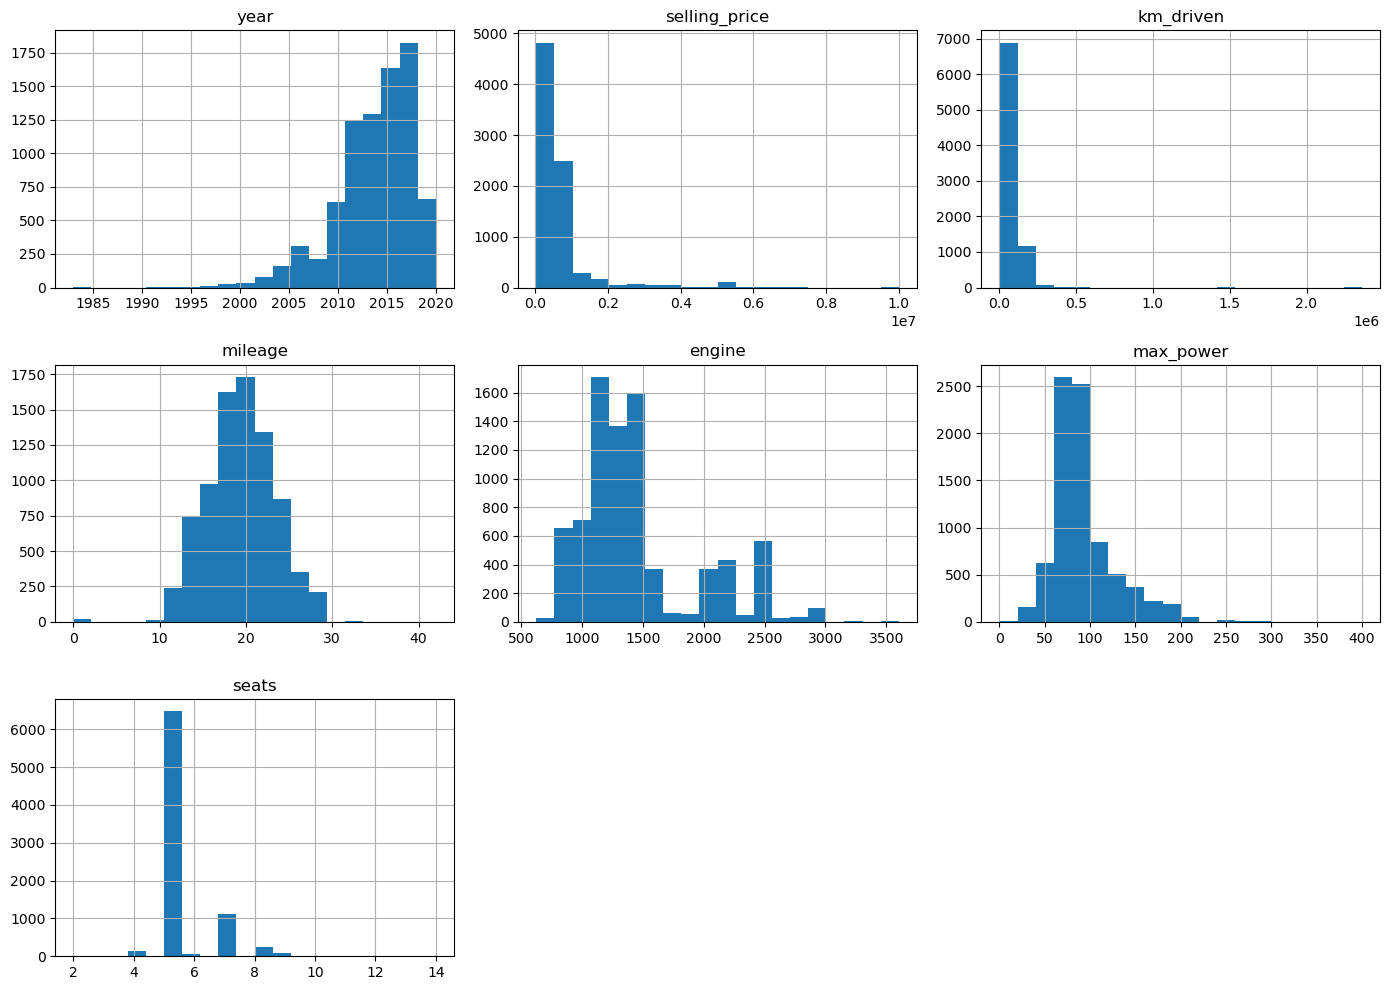

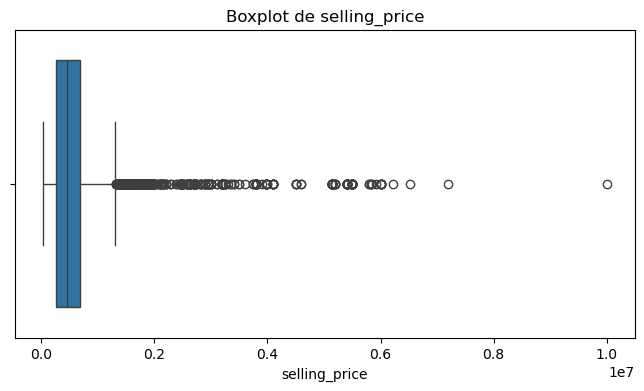

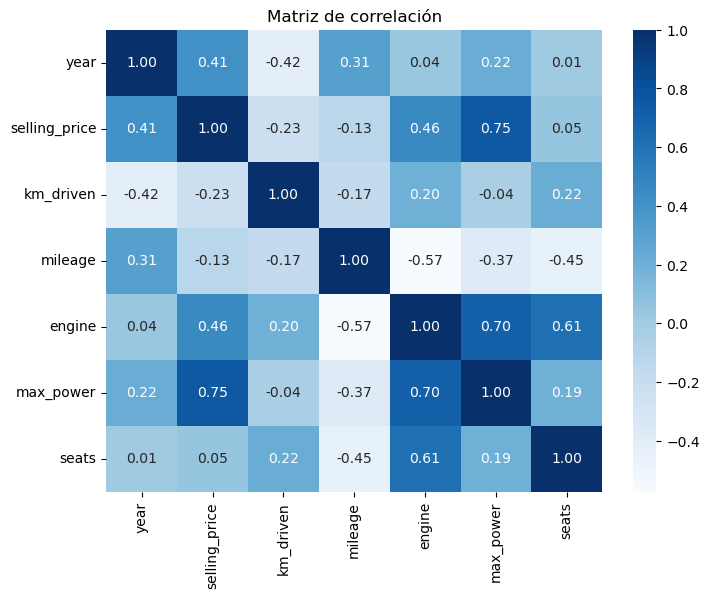

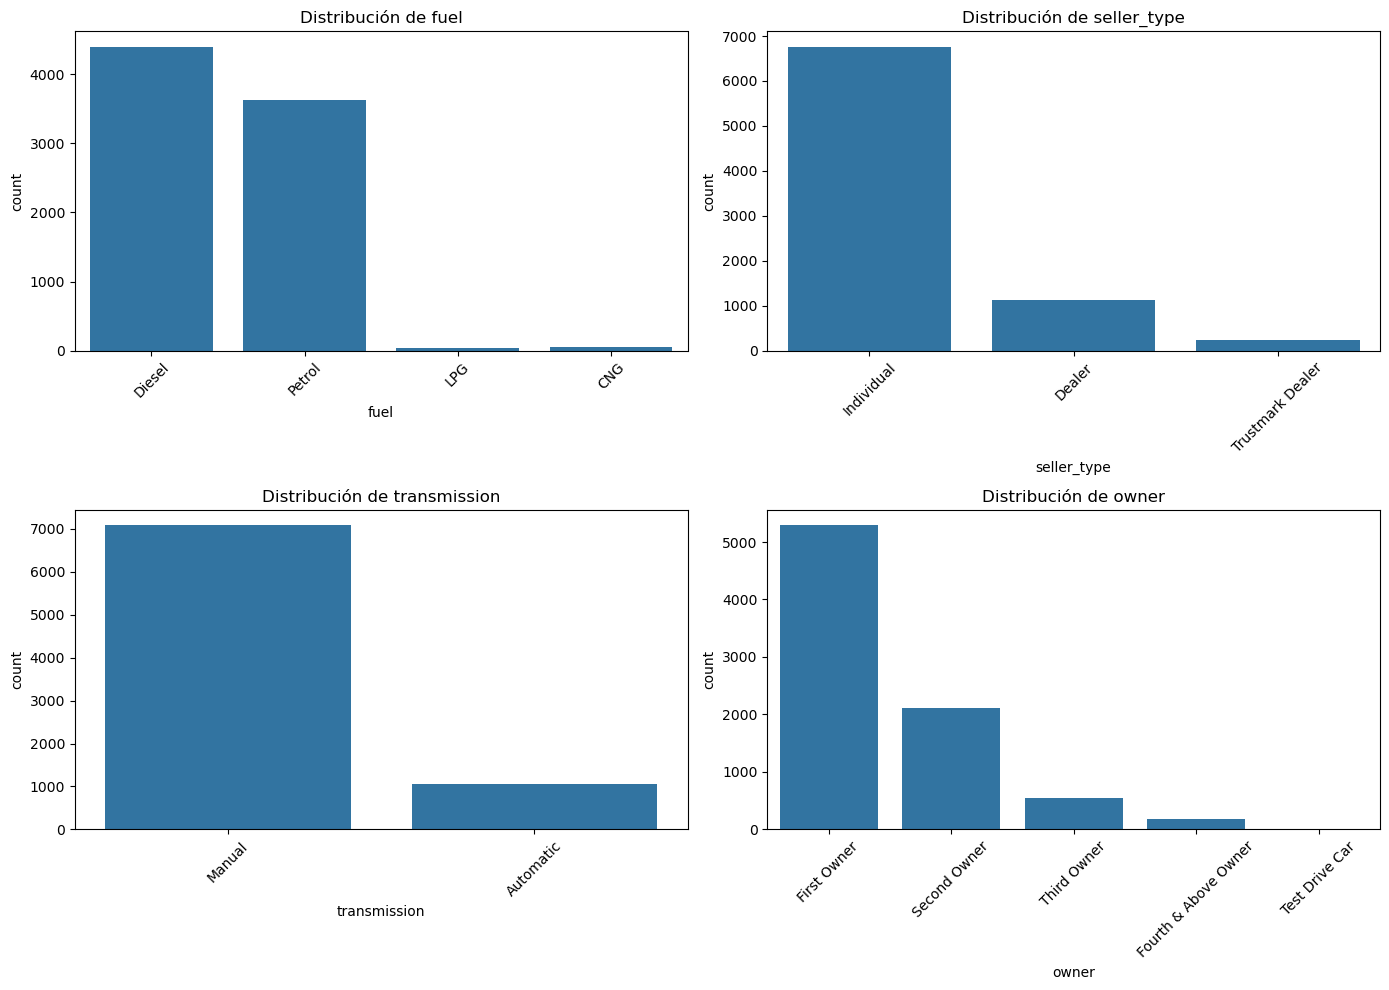

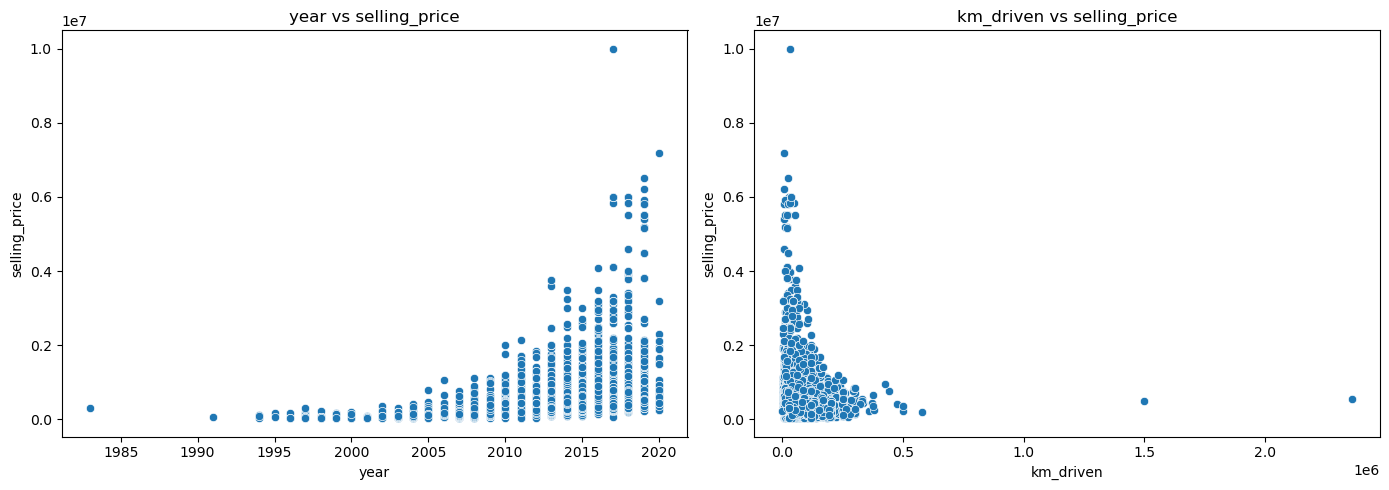

In [17]:
# Defino las variables numéricas
columnas_numericas: list[str] = [
    "year",
    "selling_price",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Represento histogramas de las variables numéricas
df_coches[columnas_numericas].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Represento un boxplot del precio de venta
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_coches["selling_price"])
plt.title("Boxplot de selling_price")
plt.xlabel("selling_price")
plt.show()

# Represento la matriz de correlación de las variables numéricas
correlacion: pd.DataFrame = df_coches[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlación")
plt.show()

# Represento algunas distribuciones categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_coches, x="fuel", ax=axes[0, 0])
axes[0, 0].set_title("Distribución de fuel")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.countplot(data=df_coches, x="seller_type", ax=axes[0, 1])
axes[0, 1].set_title("Distribución de seller_type")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.countplot(data=df_coches, x="transmission", ax=axes[1, 0])
axes[1, 0].set_title("Distribución de transmission")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.countplot(data=df_coches, x="owner", ax=axes[1, 1])
axes[1, 1].set_title("Distribución de owner")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Represento relaciones simples con el precio de venta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_coches, x="year", y="selling_price", ax=axes[0])
axes[0].set_title("year vs selling_price")

sns.scatterplot(data=df_coches, x="km_driven", y="selling_price", ax=axes[1])
axes[1].set_title("km_driven vs selling_price")

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>
¿qué conclusiones puedes sacar del análisis?

</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

A partir del análisis estadístico y exploratorio, yo diría que el dataset presenta una estructura bastante adecuada para un problema de regresión, aunque también muestra algunas características que conviene tener en cuenta. En primer lugar, el precio de venta (`selling_price`) tiene una dispersión muy alta. La media es claramente superior a la mediana, y tanto el histograma como el boxplot muestran una distribución muy asimétrica hacia la derecha, con bastantes valores extremos. Esto sugiere que existen vehículos especialmente caros que pueden influir bastante en el análisis.

También observo que la mayoría de los vehículos del conjunto de datos son relativamente recientes. La variable `year` está concentrada sobre todo entre 2010 y 2020, y en el gráfico de dispersión se aprecia una tendencia positiva entre el año y el precio de venta. En general, los coches más nuevos tienden a tener precios mayores, aunque con bastante variabilidad. En cambio, `km_driven` parece relacionarse de forma inversa con el precio: a medida que aumentan los kilómetros recorridos, el precio tiende a bajar, aunque la relación no es completamente lineal y también aparecen algunos valores atípicos.

La matriz de correlación refuerza varias de estas ideas. La relación más fuerte con `selling_price` la encuentro en `max_power`, con una correlación aproximada de `0.75`, lo que me hace pensar que la potencia del vehículo es una de las variables más relevantes para explicar su precio. También `engine` presenta una correlación positiva moderada con el precio (`0.46`) y `year` otra positiva de alrededor de `0.41`. Por el contrario, `km_driven` tiene correlación negativa con el precio (`-0.23`), lo que encaja con la intuición de que un coche más usado suele valer menos.

En las variables categóricas también veo distribuciones bastante desiguales. Predominan claramente los vehículos `Diesel` y `Petrol`, mientras que `CNG` y `LPG` aparecen en una proporción muy pequeña. Además, la mayoría de registros corresponden a ventas de tipo `Individual`, a coches con transmisión `Manual` y a vehículos de `First Owner`. Esto indica que el conjunto no está equilibrado en todas las categorías, pero al mismo tiempo refleja una distribución bastante realista del mercado de segunda mano.

Por último, me parece relevante que la variable `marca` tenga bastante variedad, aunque con un claro predominio de algunas marcas como `Maruti`. En conjunto, mi impresión es que el dataset contiene información útil para predecir el precio de venta, pero también presenta asimetrías, posibles valores extremos y distribuciones desequilibradas en algunas categorías. Por eso, en los siguientes apartados tendrá sentido preparar bien los datos antes de entrenar el modelo.

</div>

<a id='ej23'></a>
## 2.3. Preprocesamiento de datos (1.5 puntos)

En esta sección prepararemos el conjunto de datos para entrenar un modelo de regresión.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Si no lo has hecho aún, separa el conjunto de datos en atributos descriptivos (X) y variable objetivo (y).
2. Divide el conjunto de datos en los subconjuntos de entrenamiento y test con los que trabajaremos de ahora en adelante.
3. Si aplica, transforma los atributos descriptivos categóricos en atributos numéricos.
4. En el caso de ser necesario, estandariza el conjunto de datos.

</div>

In [18]:
# Separo atributos descriptivos y variable objetivo
X: pd.DataFrame = df_coches.drop(columns="selling_price")
y: pd.Series = df_coches["selling_price"]

# Divido en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=24
)

# Identifico columnas numéricas y categóricas antes de transformar
columnas_numericas: list[str] = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas: list[str] = X_train.select_dtypes(include=["object"]).columns.tolist()

print("columnas numéricas:")
print(columnas_numericas)

print("\ncolumnas categóricas:")
print(columnas_categoricas)

# Transformo variables categóricas a numéricas
X_train = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# Aseguro que train y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Estandarizo solo las variables numéricas originales
escalador = StandardScaler()

X_train[columnas_numericas] = escalador.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = escalador.transform(X_test[columnas_numericas])

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())
display(X_test.head())

columnas numéricas:
['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

columnas categóricas:
['fuel', 'seller_type', 'transmission', 'owner', 'marca']

X_train shape: (6502, 46)
X_test shape: (1626, 46)
y_train shape: (6502,)
y_test shape: (1626,)


,year,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,marca_Mercedes-Benz,marca_Mitsubishi,marca_Nissan,marca_Peugeot,marca_Renault,marca_Skoda,marca_Tata,marca_Toyota,marca_Volkswagen,marca_Volvo
2445,0.047162,-0.911028,0.239278,-0.508477,-0.349988,-0.419985,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
7,-3.139416,-1.263817,-0.837588,-1.321100,-1.540532,-1.480879,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
5169,-0.197959,0.794118,-1.444272,1.481539,1.332118,1.701803,True,False,False,True,...,False,False,False,False,False,False,True,False,False,False
806,1.272769,-1.067823,0.224111,-0.504424,-0.205077,-0.419985,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
2415,0.292283,0.941114,-0.508967,0.099471,0.741108,-0.419985,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


,year,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,marca_Mercedes-Benz,marca_Mitsubishi,marca_Nissan,marca_Peugeot,marca_Renault,marca_Skoda,marca_Tata,marca_Toyota,marca_Volkswagen,marca_Volvo
1140,-0.197959,-0.218327,0.600761,-0.911748,-0.686693,-0.419985,False,False,True,False,...,False,False,False,0,False,False,False,False,False,False
3743,0.292283,-0.871829,1.055775,-0.170052,-0.686977,-0.419985,True,False,False,True,...,False,False,False,0,False,False,False,True,False,False
5389,1.272769,-1.322615,1.988552,-0.812450,-0.631286,-0.419985,True,False,False,True,...,False,False,False,0,False,False,True,False,False,False
5720,0.537405,-0.577839,-0.862866,1.481539,1.386105,1.701803,True,False,False,True,...,False,False,False,0,False,False,False,False,False,False
4019,-0.933323,0.794118,-1.856313,3.078415,4.267280,1.701803,True,False,False,True,...,False,False,False,0,False,False,False,False,False,False


<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Si transformaste alguna variable categórica en numérica explica brevemente la elección de la técnica utilizada en cada caso.
2. Justifica por qué es necesario o no estandarizar el dato.

</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En este apartado he separado el conjunto de datos en atributos descriptivos (`X`) y variable objetivo (`y`), utilizando `selling_price` como variable a predecir. Después he dividido los datos en los subconjuntos de entrenamiento y test, que son los que usaré en los siguientes apartados.

Las variables categóricas que he transformado a numéricas han sido `fuel`, `seller_type`, `transmission`, `owner` y `marca`. Para todas ellas he utilizado one-hot encoding con `pd.get_dummies()`. He elegido esta técnica porque son variables nominales, es decir, categorías sin un orden natural, y asignarles números enteros podría introducir relaciones artificiales entre categorías que en realidad no existen. Además, he usado `drop_first=True` para evitar redundancia entre columnas y dejar una representación algo más compacta.

En cuanto a la estandarización, considero que sí era conveniente aplicarla a las variables numéricas originales: `year`, `km_driven`, `mileage`, `engine`, `max_power` y `seats`. La razón es que estas variables están medidas en escalas muy diferentes, y eso puede afectar al comportamiento de algunos modelos de regresión. Por ejemplo, `km_driven` puede tomar valores muy grandes, mientras que `seats` toma valores pequeños. Si no se estandarizan, las variables con escalas mayores pueden dominar el ajuste del modelo.

En cambio, las variables categóricas transformadas en dummies no las he estandarizado, porque ya están expresadas en formato binario y su escala es sencilla e interpretable. En conjunto, el preprocesamiento me deja los datos preparados para entrenar un modelo de regresión de forma más consistente.

</div>

<a id='ej24'></a>
## 2.4. Modelización (1 punto)

Con los datos debidamente cargados y preparados, es el momento de aplicar alguno de los métodos de regresión que hemos visto en la teoría.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Elige el método de regresión que desees utilizar para predecir el precio de venta.
2. Entrena el modelo de regresión elegido y precide el precio de los vehículos para los subconjuntos de entrenamiento y test.
3. Elige una métrica para poder evaluar el comportamiento de tu modelo.

</div>

In [19]:
# Entreno un modelo de regresión lineal y lo evaluo con MAPE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# Predigo en train y test
y_train_pred = modelo_regresion.predict(X_train)
y_test_pred = modelo_regresion.predict(X_test)

# Calculo MAPE en train y test
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)

print(f"MAPE en train: {mape_train:.4f}")
print(f"MAPE en test: {mape_test:.4f}")
print(f"MAPE en train (%): {mape_train * 100:.2f}%")
print(f"MAPE en test (%): {mape_test * 100:.2f}%")

MAPE en train: 0.4583
MAPE en test: 0.4438
MAPE en train (%): 45.83%
MAPE en test (%): 44.38%


<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Explica brevemente qué te hizo elegir la técnica de regresión que finalmente utilizaste.
2. Explica por qué elegiste la métrica con la que has evaluado al modelo.
3. Comenta los resultados obtenidos.

</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En este apartado he elegido un modelo de regresión lineal para predecir el precio de venta. He tomado esta decisión porque me parecía una técnica sencilla, fácil de interpretar y adecuada como primer modelo base para este problema. Además, después del preprocesamiento realizado, los datos ya estaban en un formato adecuado para poder aplicar este tipo de regresión sin añadir más complejidad de la necesaria.

La métrica que he utilizado para evaluar el modelo ha sido el MAPE (*Mean Absolute Percentage Error*). He elegido esta métrica porque expresa el error en términos porcentuales, lo que hace que la interpretación sea bastante directa. En un problema como este, donde la variable objetivo es el precio, me parece útil poder decir aproximadamente qué porcentaje de error medio comete el modelo en sus predicciones.

En cuanto a los resultados, el modelo obtiene un `MAPE` de `0.4583` en train y de `0.4438` en test, es decir, un error porcentual medio aproximado del 45.83 % en entrenamiento y del 44.38 % en test. En mi opinión, estos resultados muestran que el modelo no está sobreajustado, porque el error es parecido en ambos conjuntos. Sin embargo, también indican que la capacidad predictiva de esta regresión lineal es bastante limitada, ya que el porcentaje de error sigue siendo alto.

Por tanto, yo interpretaría este modelo como una primera referencia útil, pero no como un modelo especialmente preciso para este problema. Probablemente, la relación entre las variables explicativas y el precio no sea puramente lineal, y por eso una técnica más flexible podría funcionar mejor.

</div>

<a id='ej25'></a>
## 2.5. TabPFN (1 punto)

En la lectura de la publicación "[Actualizarse o quedarse atrás: lo que Kaggle me enseñó sobre algoritmos y supervivencia en ciencia de datos](https://blogs.uoc.edu/informatica/es/actualizarse-o-quedarse-atras-kaggle-ciencia-datos/)" que propusimos en el foro de la asignatura se habla de una nueva y revolucionaria técnica llamada TabPFN.

En esta sección os proponemos que la probéis con el conjunto de datos de vehículos que hemos estado preparando en esta segunda mitad de la actividad.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Instala TabPFN o tabpfn-client en tu computadora.
2. Entrena un modelo de regresión TabPFN y precide el precio de los vehículos para los subconjuntos de entrenamiento y test.
3. Utiliza la misma métrica que empleaste en el modelo anterior para poder comparar cuál modelo obtiene mejores resultados en el conjunto de datos de vehículos.

</div>

In [20]:
# Intento de carga de TabPFN
try:
    from tabpfn import TabPFNRegressor
    print("TabPFN importado correctamente.")
except Exception as e:
    print("No fue posible importar TabPFN en este entorno.")
    print(type(e).__name__, ":", e)

No fue posible importar TabPFN en este entorno.
ModuleNotFoundError : No module named 'tabpfn'


<div class="alert alert-block alert-info">
<strong>Análisis:</strong>
evalúa y comenta los resultados obtenidos con TabPFN respecto al modelo que utilizaste en el subapartado anterior.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

En este apartado he intentado utilizar TabPFN para comparar su rendimiento con el modelo del subapartado anterior. Sin embargo, en mi entorno de trabajo han surgido problemas técnicos al importar la librería, por lo que no he podido completar la ejecución del modelo.

He preferido no incluir resultados que no haya podido obtener realmente. En caso de haber funcionado correctamente, la comparación la habría realizado con la misma métrica utilizada en el apartado 2.4, es decir, el `MAPE`, para mantener un criterio homogéneo de evaluación.

Por tanto, este subapartado ha quedado incompleto por una limitación técnica del entorno y no porque no haya quedado claro el procedimiento a seguir.

</div>

## Fuentes utilizadas

Para la realización de esta PEC he utilizado las siguientes fuentes del bloque 3 de la asignatura:

- Material teórico sobre métodos supervisados.
- Material sobre sesgo algorítmico.
- Vídeos del bloque 3.

Además, para la parte práctica he trabajado con los ficheros proporcionados en la actividad:

- EMNIST_sample.pickle.
- Car details v3.csv.
- environment_uoc20252pec3.yml.

También he utilizado las librerías incluidas en el entorno de trabajo de la PEC, especialmente `scikit-learn`, `pandas`, `matplotlib`, `seaborn` y `umap-learn`.